In [288]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import (
    HuberRegressor,
    LinearRegression,
    LogisticRegression,
    QuantileRegressor,
    Ridge,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    PolynomialFeatures,
    SplineTransformer,
    StandardScaler,
)
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer

RANDOM_STATE = 280926

In [289]:
train = pd.read_csv("QSAR_challenge_train_80pct.csv")
test = pd.read_csv("QSAR_challenge_test_20pct_NO_TARGETS.csv")

In [290]:
train.shape

(623, 12)

In [291]:
train

,sample_id,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],regression_target,classification_target
0,2234-13-1,8.0,7.157,2.41,0.21,6.55,0.97,0.0,0.0,0.0,2.58,3
1,108-42-9,1.0,0.000,1.23,0.20,2.13,0.68,0.0,1.0,NaN,0.33,3
2,106-43-4,1.0,0.000,1.23,0.22,3.21,0.84,0.0,0.0,0.0,1.80,1
3,108-87-2,0.0,0.000,0.00,0.34,3.48,1.67,0.0,0.0,0.0,2.32,1
4,101-81-5,0.0,5.614,2.21,0.19,4.15,1.47,0.0,0.0,0.0,2.97,1
...,...,...,...,...,...,...,...,...,...,...,...,...
618,17700-09-3,3.0,0.000,1.49,0.18,3.70,0.69,0.0,1.0,4.0,2.20,1
619,5915-41-3,1.0,3.056,1.21,0.21,2.89,1.90,0.0,1.0,0.0,0.84,3
620,39515-41-8/64257-84-7,0.0,6.428,2.25,0.19,3.56,2.92,0.0,1.0,15.0,3.04,3
621,26644-46-2,6.0,4.043,0.16,0.29,1.40,1.86,2.0,1.0,2.0,0.00,3


In [292]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sample_id              623 non-null    str    
 1   nHM                    612 non-null    float64
 2   piPC09                 610 non-null    float64
 3   PCD                    616 non-null    float64
 4   X2Av                   611 non-null    float64
 5   MLOGP                  610 non-null    float64
 6   ON1V                   609 non-null    float64
 7   N-072                  604 non-null    float64
 8   B02[C-N]               616 non-null    float64
 9   F04[C-O]               607 non-null    float64
 10  regression_target      623 non-null    float64
 11  classification_target  623 non-null    int64  
dtypes: float64(10), int64(1), str(1)
memory usage: 58.5 KB


In [293]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  156 non-null    str    
 1   nHM        153 non-null    float64
 2   piPC09     152 non-null    float64
 3   PCD        151 non-null    float64
 4   X2Av       153 non-null    float64
 5   MLOGP      154 non-null    float64
 6   ON1V       154 non-null    float64
 7   N-072      153 non-null    float64
 8   B02[C-N]   153 non-null    float64
 9   F04[C-O]   153 non-null    float64
dtypes: float64(9), str(1)
memory usage: 12.3 KB


In [294]:
def visualize_col_distr(df, n_cols=3, n_rows=4):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
    axes = axes.flatten()

    for i, col in enumerate(df.columns):
        if col == "sample_id":
            continue
        axes[i].hist(df[col], bins=20, edgecolor="black")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
        axes[i].set_title(f"{col} distribution")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

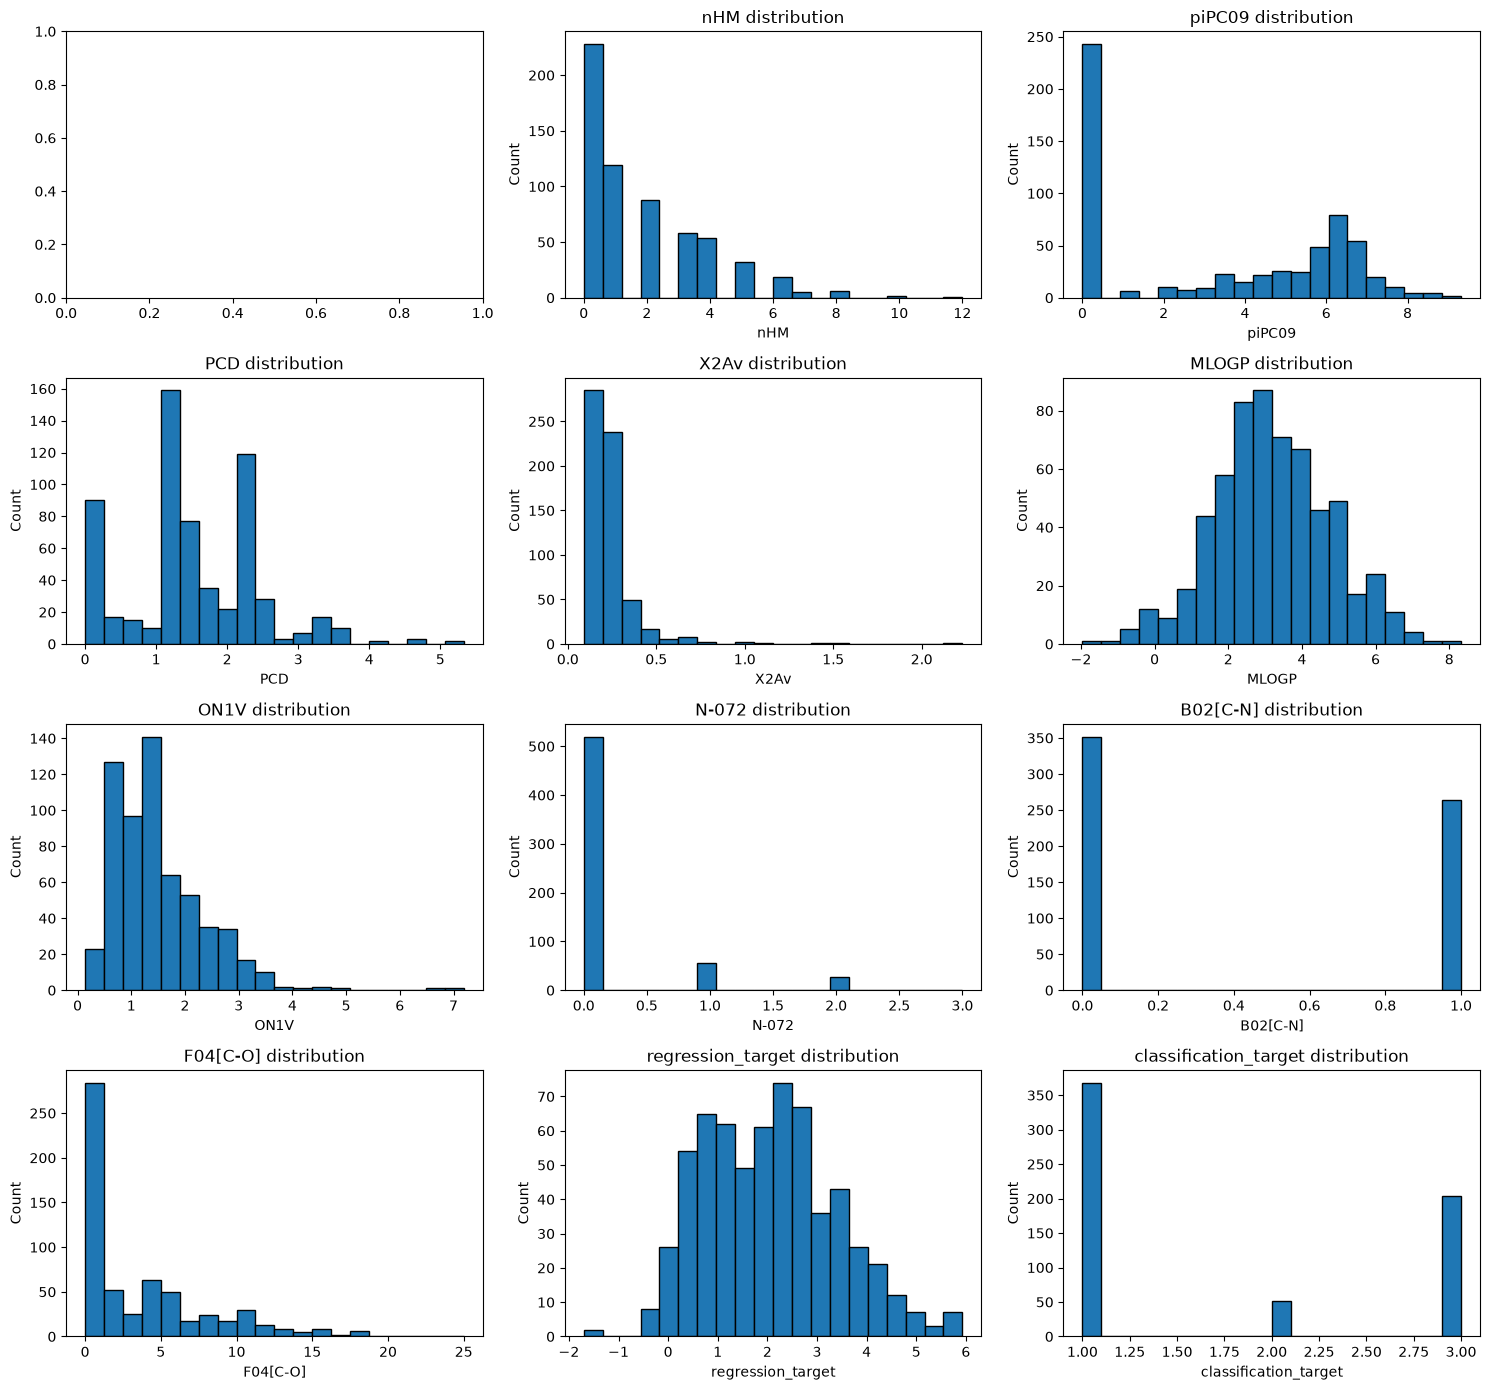

In [295]:
visualize_col_distr(train)

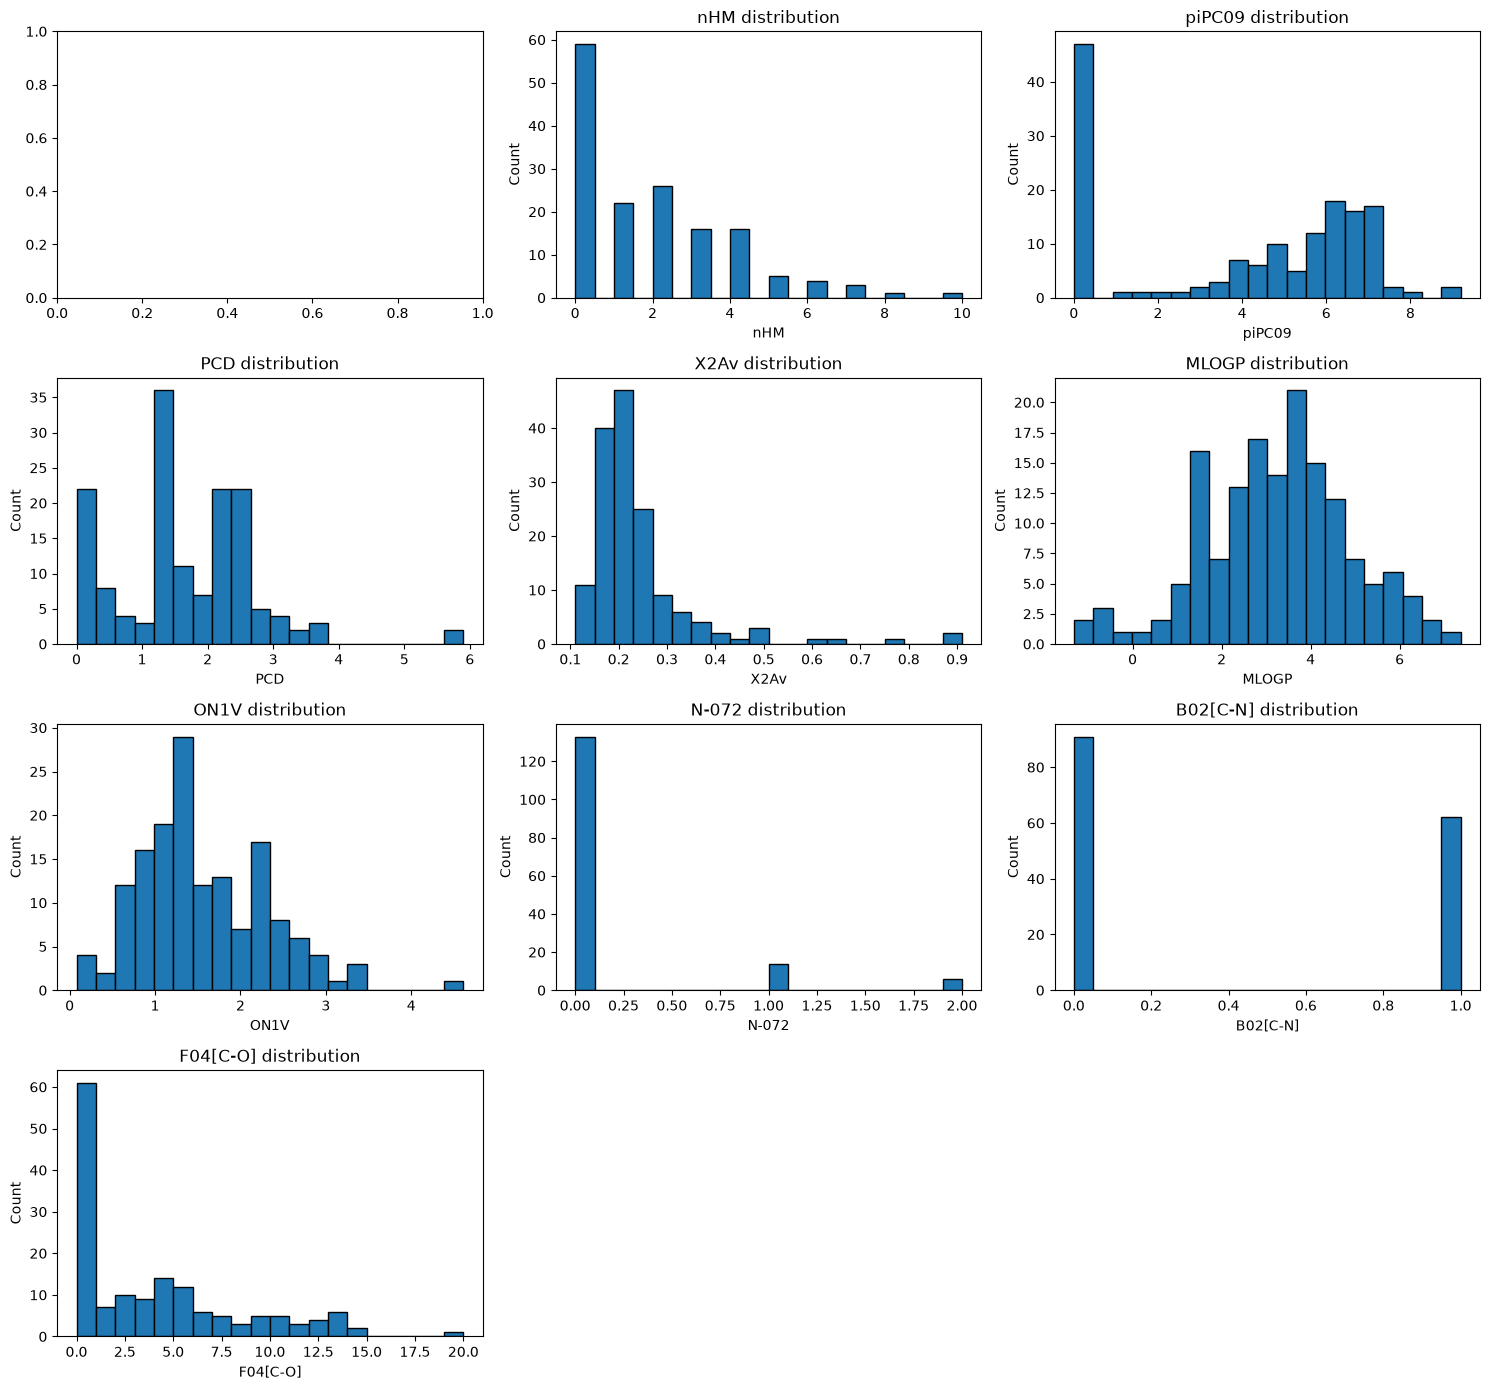

In [296]:
visualize_col_distr(test)

In [297]:
train.describe()

,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],regression_target,classification_target
count,612.000000,610.000000,616.000000,611.000000,610.000000,609.000000,604.000000,616.000000,607.000000,623.000000,623.000000
mean,1.754902,3.349279,1.532987,0.236563,3.189770,1.496700,0.188742,0.428571,3.598023,2.046260,1.736758
std,1.993950,2.970165,0.934499,0.156650,1.584938,0.854107,0.506154,0.495274,4.491267,1.335059,0.922066
min,0.000000,0.000000,0.000000,0.090000,-1.960000,0.140000,0.000000,0.000000,0.000000,-1.700000,1.000000
25%,0.000000,0.000000,1.210000,0.170000,2.190000,0.860000,0.000000,0.000000,0.000000,0.985000,1.000000
50%,1.000000,4.025000,1.380000,0.200000,3.115000,1.260000,0.000000,0.000000,2.000000,2.000000,1.000000
75%,3.000000,6.187500,2.280000,0.240000,4.207500,1.990000,0.000000,1.000000,6.000000,2.865000,3.000000
max,12.000000,9.316000,5.330000,2.230000,8.320000,7.190000,3.000000,1.000000,25.000000,5.930000,3.000000


In [298]:
test.describe()

,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O]
count,153.000000,152.000000,151.000000,153.000000,154.000000,154.000000,153.000000,153.000000,153.000000
mean,1.790850,3.964388,1.639404,0.237386,3.267338,1.557338,0.169935,0.405229,3.705882
std,2.011983,2.928426,1.059657,0.121356,1.650596,0.763523,0.470034,0.492549,4.332986
min,0.000000,0.000000,0.000000,0.110000,-1.320000,0.080000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.190000,0.170000,2.220000,1.045000,0.000000,0.000000,0.000000
50%,1.000000,5.023000,1.500000,0.210000,3.340000,1.365000,0.000000,0.000000,2.000000
75%,3.000000,6.427750,2.370000,0.250000,4.272500,2.130000,0.000000,1.000000,6.000000
max,10.000000,9.194000,5.900000,0.910000,7.370000,4.610000,2.000000,1.000000,20.000000


Possibly, removing outliers or adressing the mshould help (for columns F04[C-O], N-072, ON1V, X2Av)

In [299]:
def visualize_relationship(
    df,
    target_column="regression_target",
    exclude=["sample_id", "regression_target", "classification_target"],
    n_rows=3,
    n_cols=3,
):
    features = [feature for feature in df.columns if feature not in exclude]
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 10))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        ax = axes[i]
        ax.scatter(df[feature], df[target_column], alpha=0.7, color="tab:blue")

        ax.set_xlabel(f"{feature}")
        ax.set_ylabel(target_column)
        ax.set_title(f"{feature} vs Regression target")
    plt.tight_layout()
    plt.show()

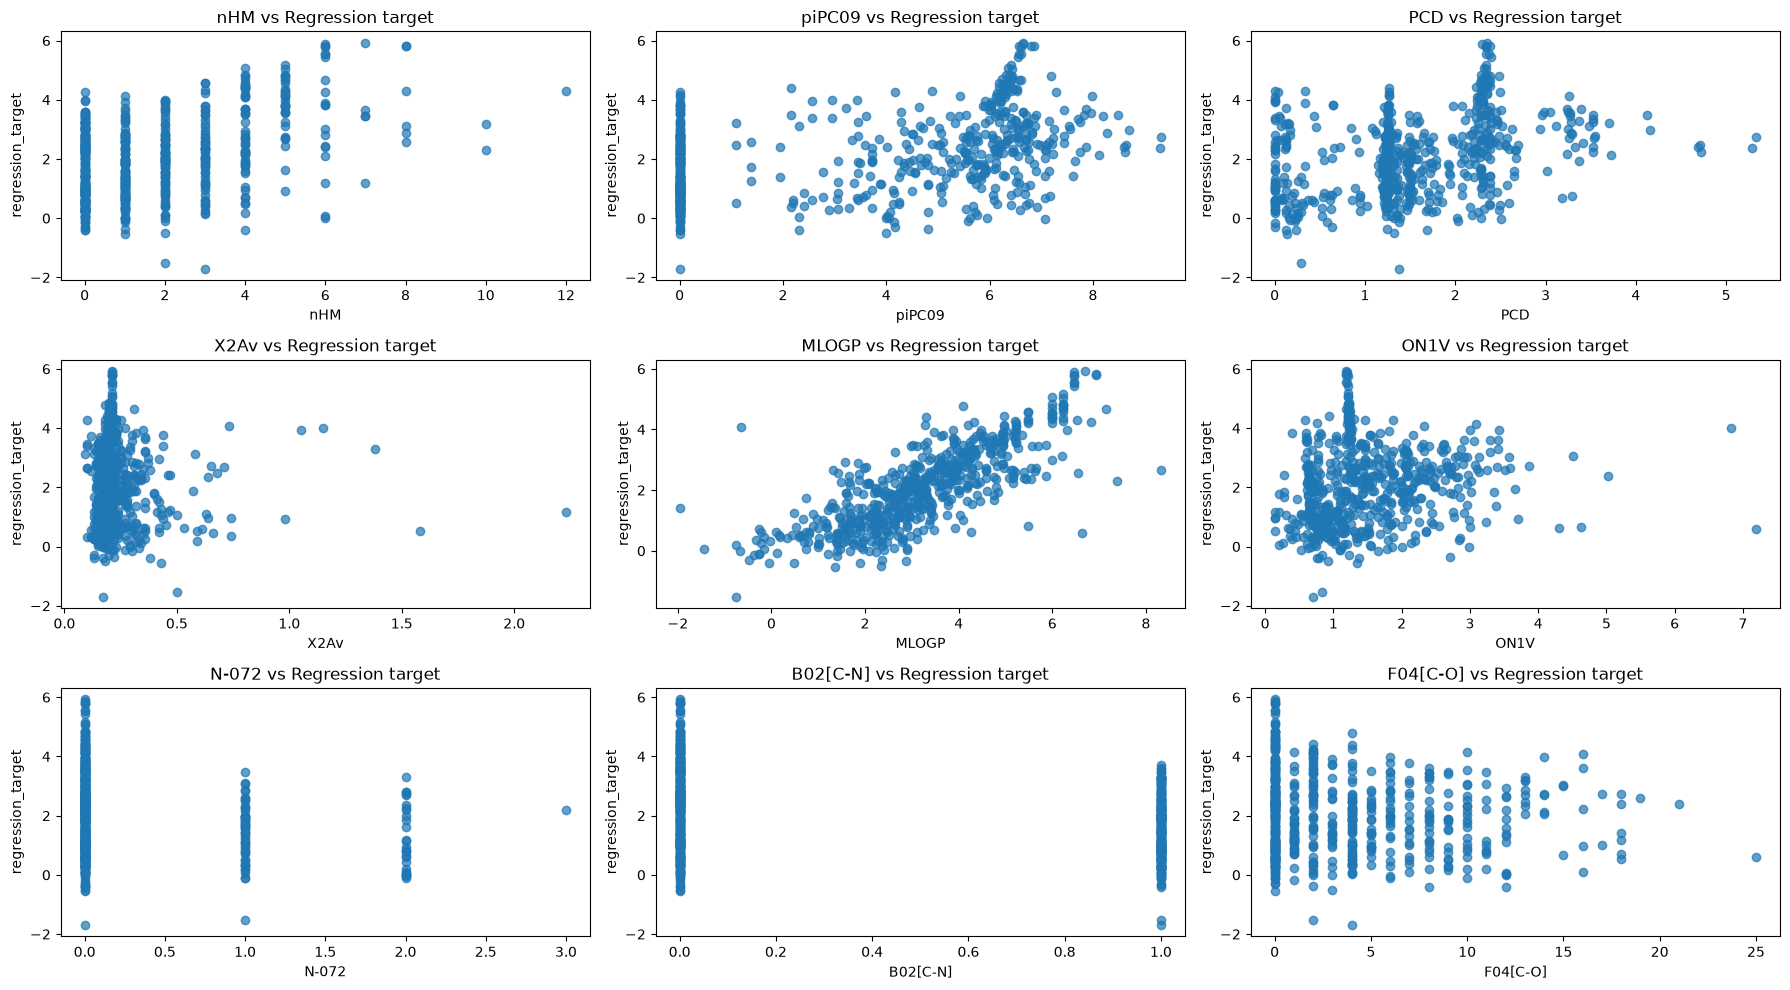

In [300]:
visualize_relationship(train)

In [301]:
train.isna().sum()

sample_id                 0
nHM                      11
piPC09                   13
PCD                       7
X2Av                     12
MLOGP                    13
ON1V                     14
N-072                    19
B02[C-N]                  7
F04[C-O]                 16
regression_target         0
classification_target     0
dtype: int64

In [302]:
train[train.isnull().any(axis=1)]

,sample_id,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],regression_target,classification_target
1,108-42-9,1.0,0.000,1.23,0.20,2.13,0.68,0.0,1.0,NaN,0.33,3
6,610-39-9,0.0,4.808,1.74,0.14,2.24,0.99,NaN,1.0,8.0,0.21,3
7,2042-14-0,NaN,0.000,1.50,0.15,1.70,0.92,0.0,1.0,7.0,1.02,1
9,25311-71-1,2.0,NaN,1.39,0.28,2.99,2.96,0.0,1.0,14.0,2.12,3
10,87-40-1,3.0,0.000,1.25,0.21,3.62,0.77,0.0,0.0,NaN,2.84,1
...,...,...,...,...,...,...,...,...,...,...,...,...
589,2050-67-1,2.0,6.149,2.29,NaN,NaN,1.25,0.0,0.0,0.0,2.63,3
596,16219-75-3,0.0,NaN,0.63,0.22,2.96,1.46,0.0,0.0,0.0,2.05,3
599,119-56-2,NaN,5.768,2.15,0.18,3.66,1.44,0.0,0.0,4.0,1.82,3
600,591-35-5,2.0,0.000,1.24,0.21,2.73,NaN,0.0,0.0,1.0,1.92,1


Too many rows and columns with at least one missing value, need to impute

In [303]:
mice_im = IterativeImputer(random_state=RANDOM_STATE)
imputation_train = train.drop(
    columns=["sample_id", "regression_target", "classification_target"],
)
imputed_train = mice_im.fit_transform(imputation_train)
imputation_train = pd.DataFrame(imputed_train, columns=imputation_train.columns)
imputation_train["regression_target"] = train["regression_target"]
imputation_train["classification_target"] = train["classification_target"]

In [304]:
imputation_train.isna().sum()

nHM                      0
piPC09                   0
PCD                      0
X2Av                     0
MLOGP                    0
ON1V                     0
N-072                    0
B02[C-N]                 0
F04[C-O]                 0
regression_target        0
classification_target    0
dtype: int64

In [305]:
imputation_train.describe()

,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],regression_target,classification_target
count,623.000000,623.000000,623.000000,623.000000,623.000000,623.000000,623.000000,623.000000,623.000000,623.000000,623.000000
mean,1.754636,3.362573,1.530445,0.236503,3.191443,1.501794,0.192301,0.429515,3.589946,2.046260,1.736758
std,1.980584,2.978266,0.936917,0.155433,1.579139,0.851629,0.500728,0.492994,4.444688,1.335059,0.922066
min,-0.520837,-1.350061,-1.054821,0.090000,-1.960000,0.140000,-0.210224,0.000000,0.000000,-1.700000,1.000000
25%,0.000000,0.000000,1.210000,0.170000,2.190000,0.860000,0.000000,0.000000,0.000000,0.985000,1.000000
50%,1.000000,4.078000,1.380000,0.200000,3.110000,1.260000,0.000000,0.000000,2.000000,2.000000,1.000000
75%,3.000000,6.190500,2.280000,0.240000,4.195000,1.995000,0.000000,1.000000,6.000000,2.865000,3.000000
max,12.000000,9.316000,5.330000,2.230000,8.320000,7.190000,3.000000,1.000000,25.000000,5.930000,3.000000


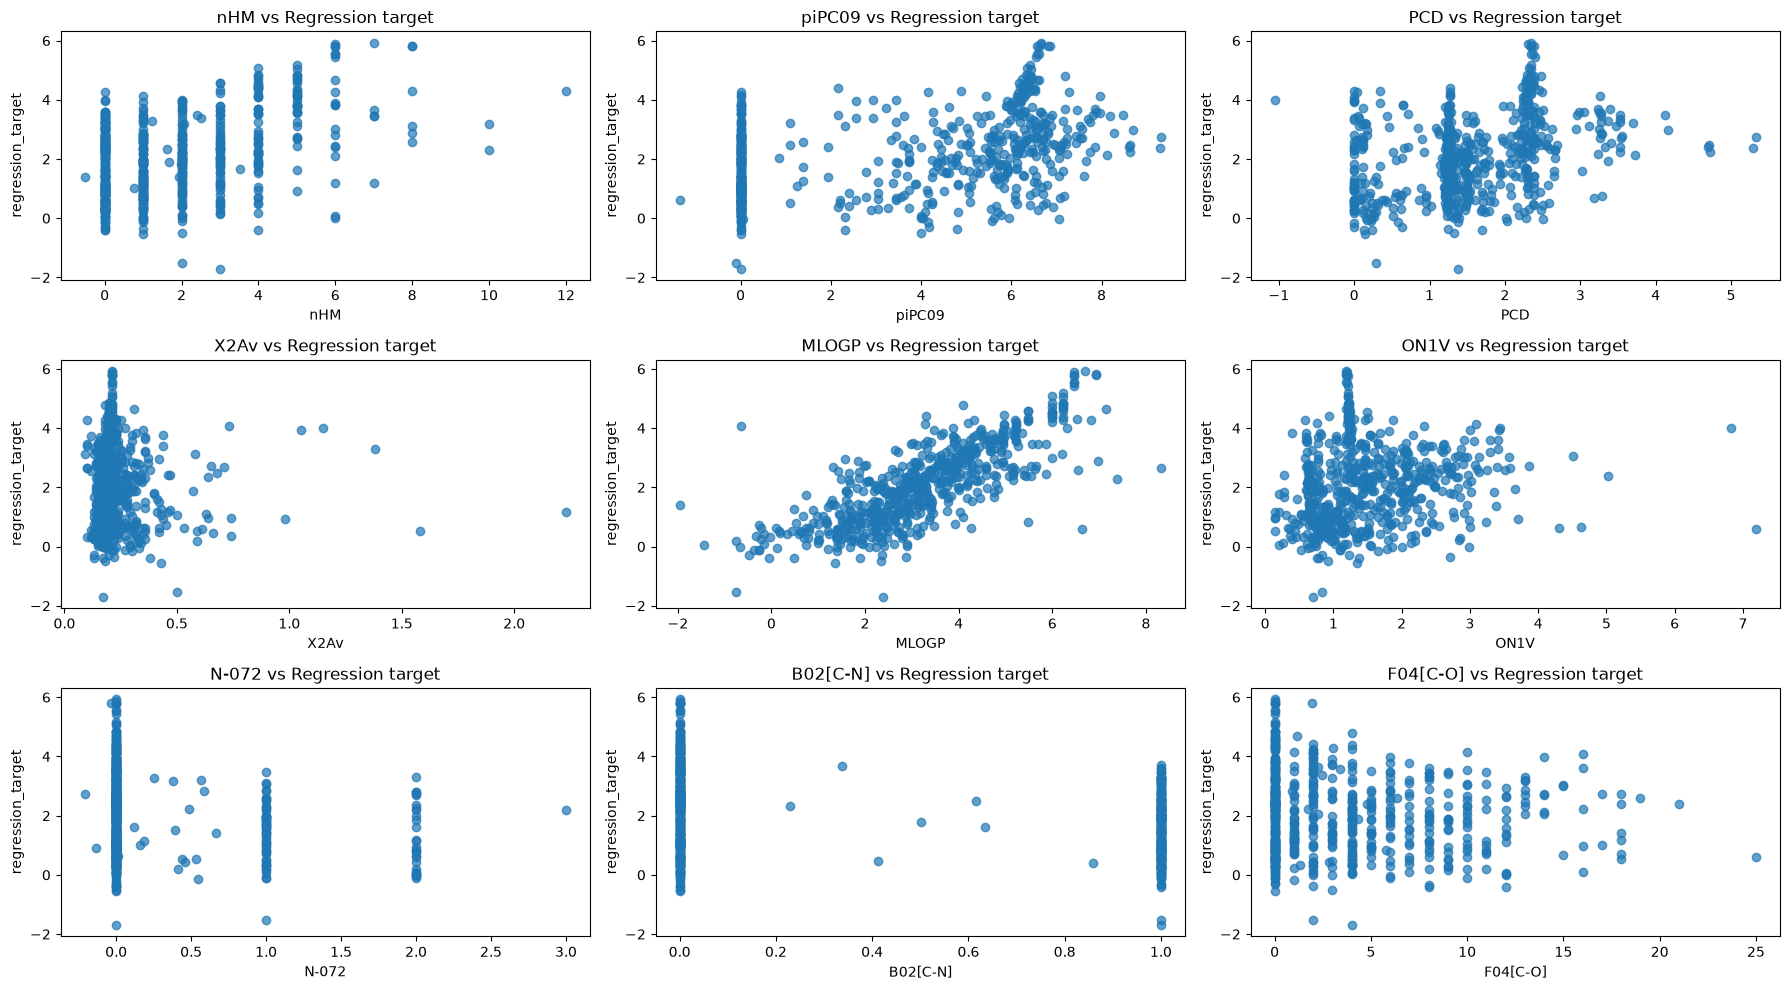

In [306]:
visualize_relationship(imputation_train)

In [307]:
imputation_train["nHM"] = imputation_train["nHM"].round().clip(lower=0)
imputation_train["N-072"] = imputation_train["N-072"].round().clip(lower=0)
imputation_train["B02[C-N]"] = imputation_train["B02[C-N]"].round().clip(lower=0)
imputation_train["F04[C-O]"] = imputation_train["F04[C-O]"].round().clip(lower=0)

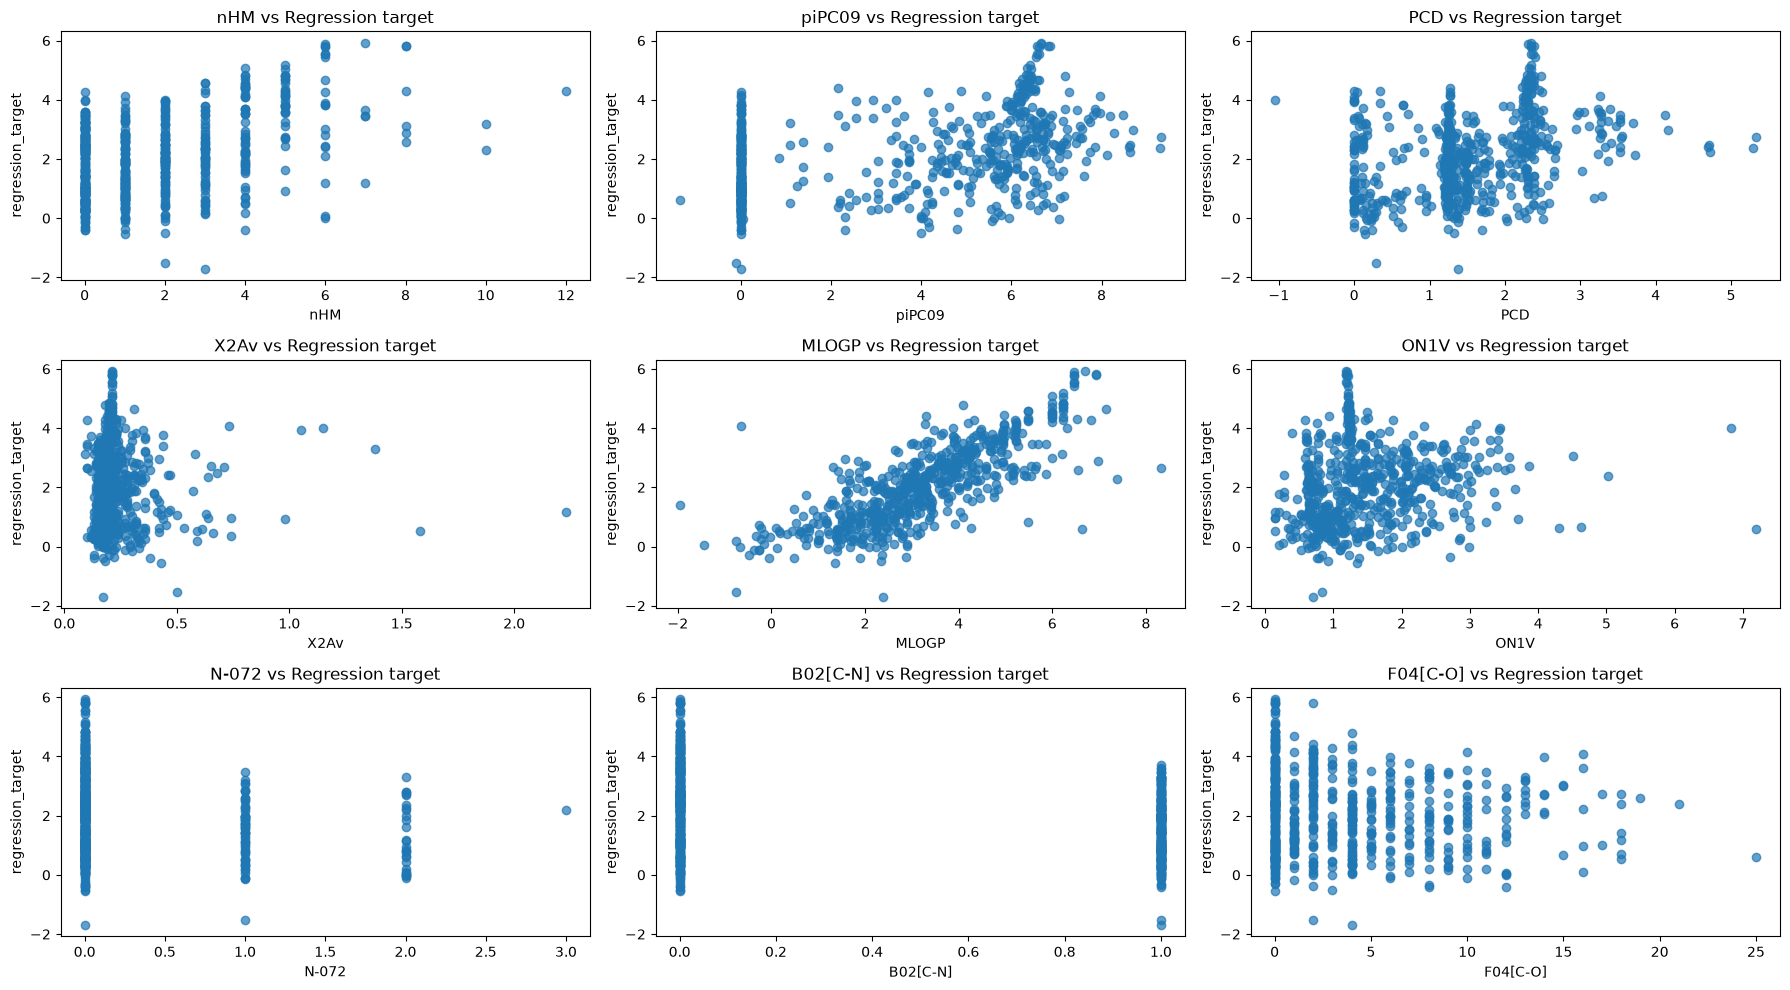

In [308]:
visualize_relationship(imputation_train)

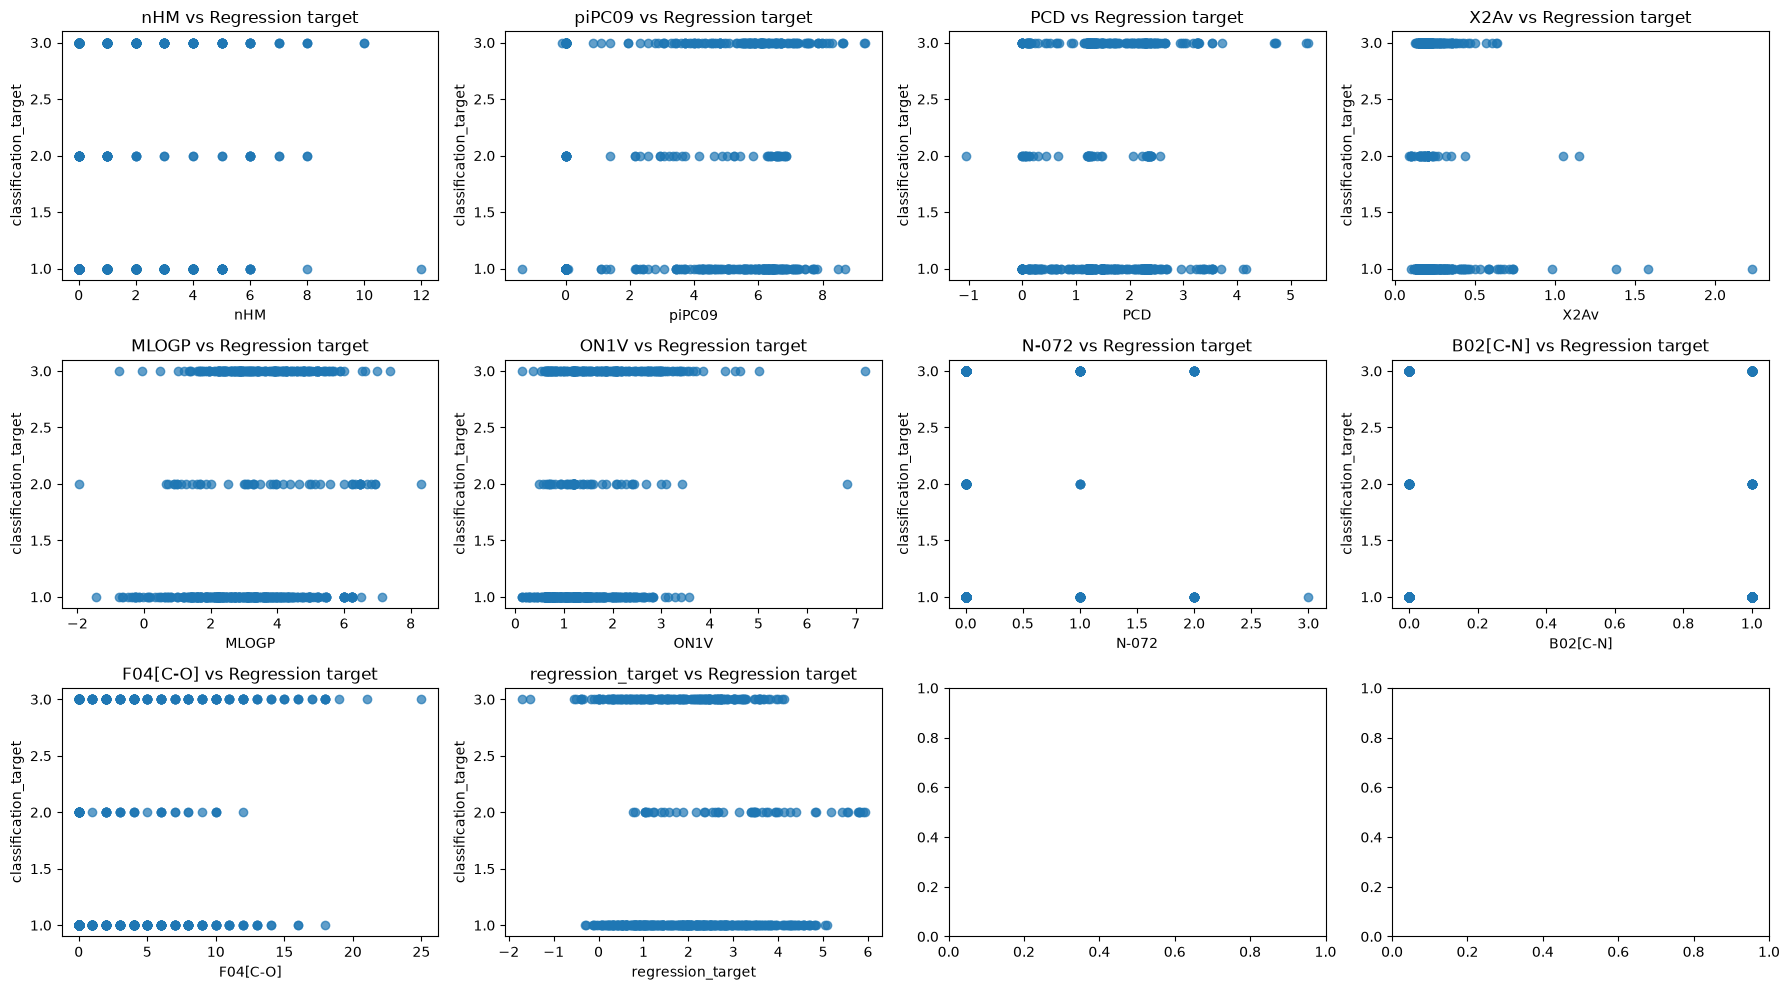

In [309]:
visualize_relationship(
    imputation_train,
    target_column="classification_target",
    exclude=["classification_target"],
    n_cols=4,
)

In [310]:
imputation_train.corr(method="pearson")

,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],regression_target,classification_target
nHM,1.000000,0.102151,-0.044144,0.205792,0.405471,-0.233986,-0.083642,-0.258260,-0.130902,0.455111,0.022002
piPC09,0.102151,1.000000,0.725593,-0.260871,0.512286,0.473705,0.142686,0.031433,0.288429,0.444803,0.221732
PCD,-0.044144,0.725593,1.000000,-0.439461,0.442766,0.118250,-0.037182,0.106724,0.106774,0.357994,0.113474
X2Av,0.205792,-0.260871,-0.439461,1.000000,-0.113545,0.028287,-0.055896,-0.213400,-0.103000,-0.040822,-0.054624
MLOGP,0.405471,0.512286,0.442766,-0.113545,1.000000,0.249068,-0.221876,-0.358688,-0.087142,0.778584,0.182929
ON1V,-0.233986,0.473705,0.118250,0.028287,0.249068,1.000000,0.220913,0.124297,0.558400,0.152250,0.330277
N-072,-0.083642,0.142686,-0.037182,-0.055896,-0.221876,0.220913,1.000000,0.391139,0.182895,-0.193788,0.014953
B02[C-N],-0.258260,0.031433,0.106724,-0.213400,-0.358688,0.124297,0.391139,1.000000,0.212809,-0.335381,-0.096597
F04[C-O],-0.130902,0.288429,0.106774,-0.103000,-0.087142,0.558400,0.182895,0.212809,1.000000,-0.108347,0.269211
regression_target,0.455111,0.444803,0.357994,-0.040822,0.778584,0.152250,-0.193788,-0.335381,-0.108347,1.000000,-0.087416


In [311]:
imputation_train.corr(method="spearman")

,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],regression_target,classification_target
nHM,1.000000,0.062027,-0.006833,0.453168,0.310027,-0.253159,-0.068424,-0.209010,-0.062952,0.364028,-0.012001
piPC09,0.062027,1.000000,0.787201,-0.334986,0.531414,0.563837,0.109828,0.005632,0.235690,0.458363,0.207645
PCD,-0.006833,0.787201,1.000000,-0.567991,0.459568,0.238050,-0.014911,0.123247,0.178580,0.377103,0.106917
X2Av,0.453168,-0.334986,-0.567991,1.000000,-0.033767,-0.049843,-0.054640,-0.304300,-0.211118,0.044269,-0.011137
MLOGP,0.310027,0.531414,0.459568,-0.033767,1.000000,0.273543,-0.229790,-0.370119,-0.139615,0.790804,0.195406
ON1V,-0.253159,0.563837,0.238050,-0.049843,0.273543,1.000000,0.287456,0.146808,0.466473,0.230357,0.298131
N-072,-0.068424,0.109828,-0.014911,-0.054640,-0.229790,0.287456,1.000000,0.414464,0.277524,-0.197460,0.008902
B02[C-N],-0.209010,0.005632,0.123247,-0.304300,-0.370119,0.146808,0.414464,1.000000,0.264131,-0.323793,-0.102497
F04[C-O],-0.062952,0.235690,0.178580,-0.211118,-0.139615,0.466473,0.277524,0.264131,1.000000,-0.106585,0.255010
regression_target,0.364028,0.458363,0.377103,0.044269,0.790804,0.230357,-0.197460,-0.323793,-0.106585,1.000000,-0.056580


## With mean imputation

In [ ]:
mean_im = SimpleImputer(strategy="mean")
imputation_train_mean = train.drop(
    columns=["sample_id", "regression_target", "classification_target"],
)
imputed_train_mean = mean_im.fit_transform(imputation_train_mean)
imputation_train_mean = pd.DataFrame(
    imputed_train_mean, columns=imputation_train_mean.columns
)
imputation_train_mean["regression_target"] = train["regression_target"]
imputation_train_mean["classification_target"] = train["classification_target"]

In [313]:
imputation_train_mean.isna().sum()

nHM                      0
piPC09                   0
PCD                      0
X2Av                     0
MLOGP                    0
ON1V                     0
N-072                    0
B02[C-N]                 0
F04[C-O]                 0
regression_target        0
classification_target    0
dtype: int64

In [ ]:
imputation_train_mean["nHM"] = imputation_train_mean["nHM"].round().clip(lower=0)
imputation_train_mean["N-072"] = imputation_train_mean["N-072"].round().clip(lower=0)
imputation_train_mean["B02[C-N]"] = (
    imputation_train_mean["B02[C-N]"].round().clip(lower=0)
)
imputation_train_mean["F04[C-O]"] = (
    imputation_train_mean["F04[C-O]"].round().clip(lower=0)
)

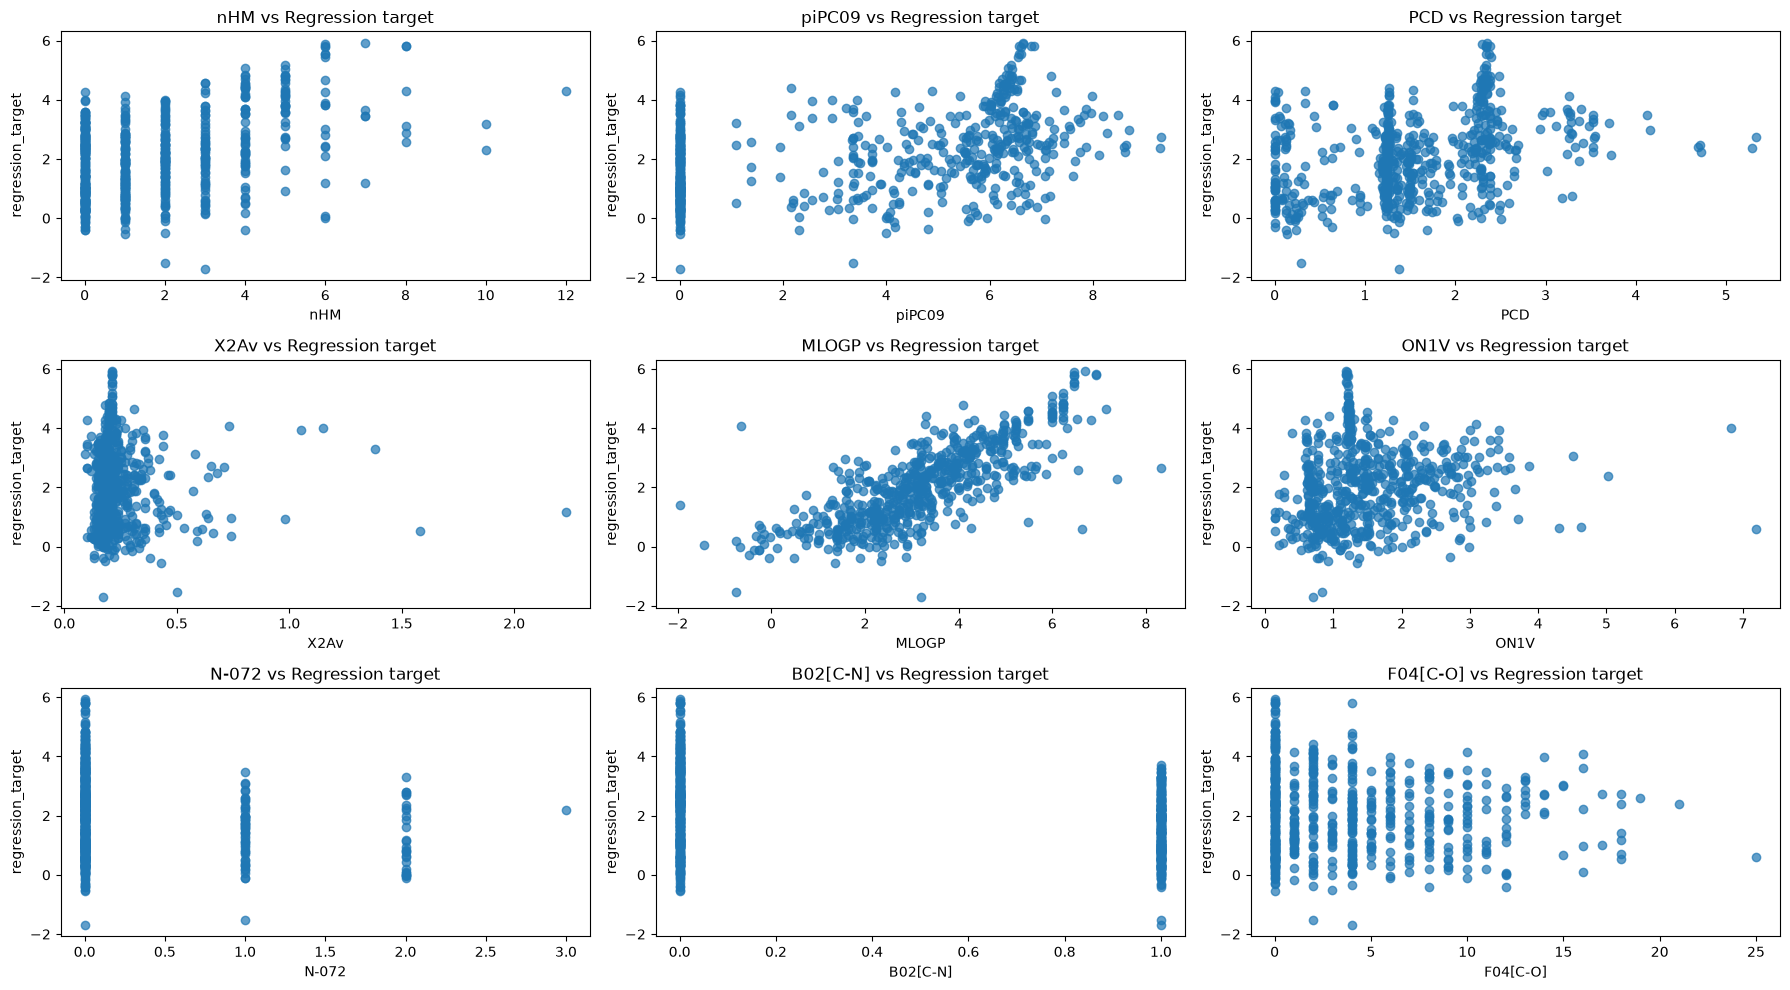

In [315]:
visualize_relationship(imputation_train_mean)

## With median imputation

In [ ]:
median_im = SimpleImputer(strategy="median")
imputation_train_median = train.drop(
    columns=["sample_id", "regression_target", "classification_target"],
)
imputed_train_median = median_im.fit_transform(imputation_train_median)
imputation_train_median = pd.DataFrame(
    imputed_train_mean, columns=imputation_train_median.columns
)
imputation_train_median["regression_target"] = train["regression_target"]
imputation_train_median["classification_target"] = train["classification_target"]

In [317]:
imputation_train_median.isna().sum()

nHM                      0
piPC09                   0
PCD                      0
X2Av                     0
MLOGP                    0
ON1V                     0
N-072                    0
B02[C-N]                 0
F04[C-O]                 0
regression_target        0
classification_target    0
dtype: int64

In [ ]:
imputation_train_median["nHM"] = imputation_train_median["nHM"].round().clip(lower=0)
imputation_train_median["N-072"] = (
    imputation_train_median["N-072"].round().clip(lower=0)
)
imputation_train_median["B02[C-N]"] = (
    imputation_train_median["B02[C-N]"].round().clip(lower=0)
)
imputation_train_median["F04[C-O]"] = (
    imputation_train_median["F04[C-O]"].round().clip(lower=0)
)

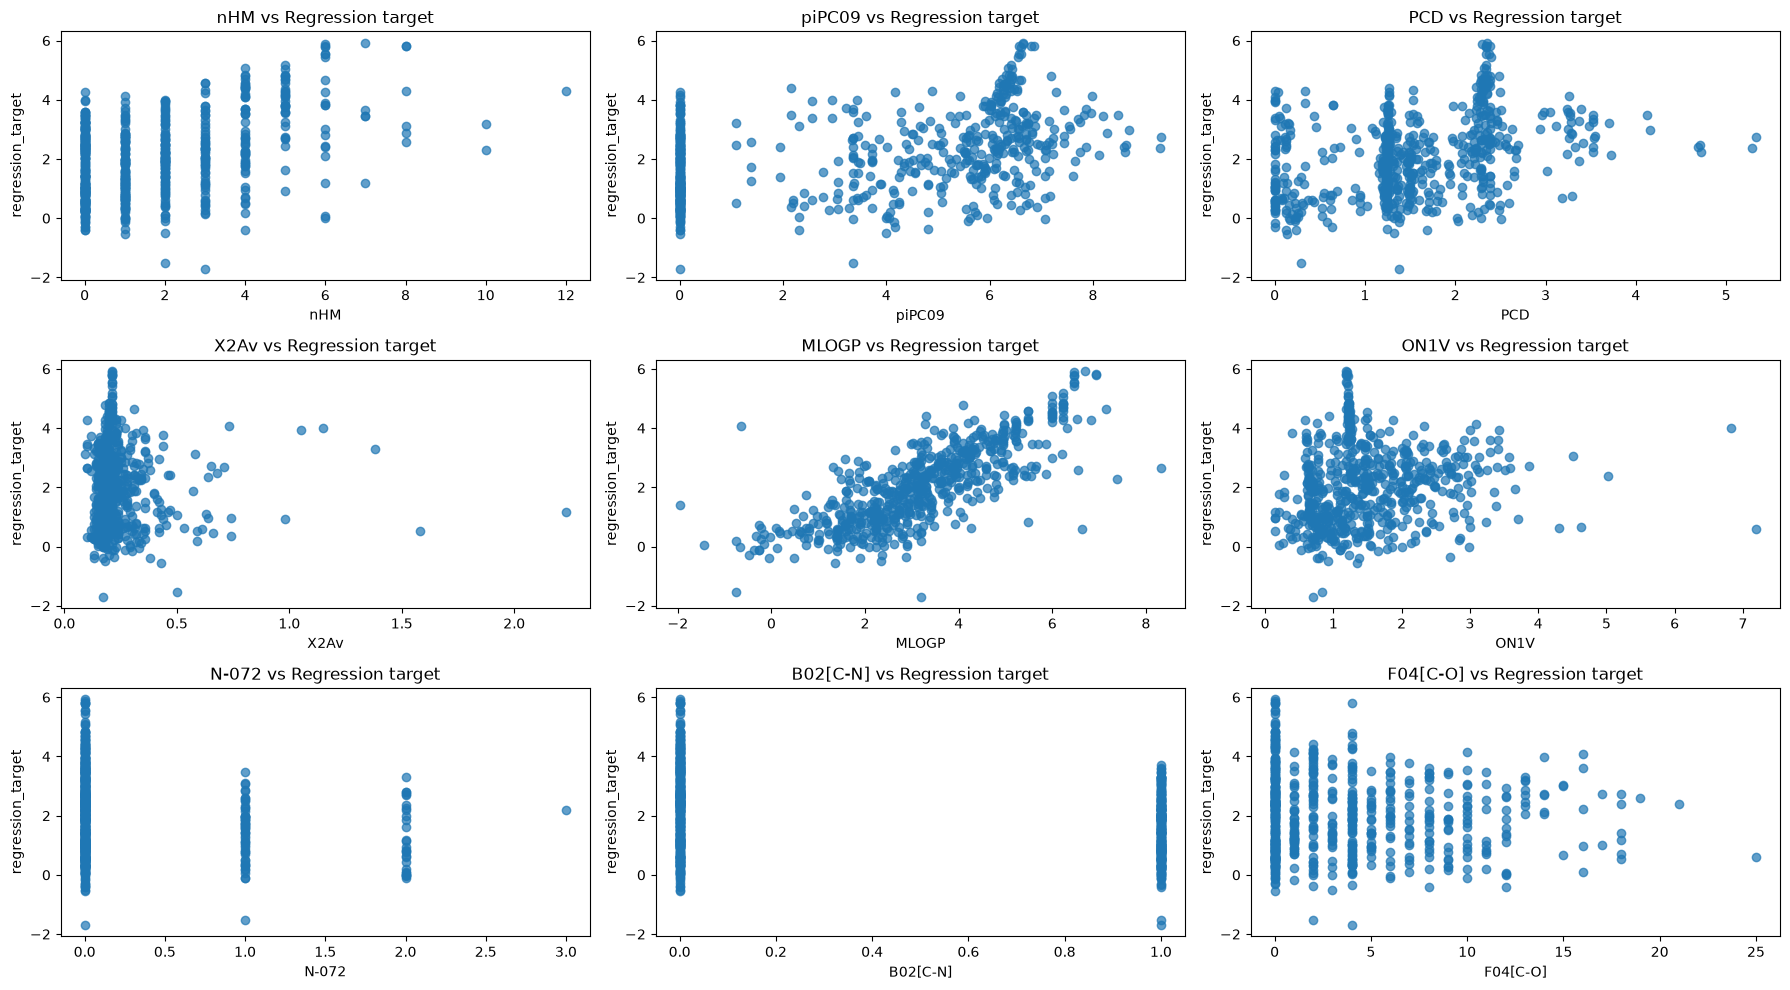

In [319]:
visualize_relationship(imputation_train_median)

In [ ]:
X = imputation_train.drop(columns=["regression_target", "classification_target"])
X_mean = imputation_train_mean.drop(
    columns=["regression_target", "classification_target"]
)
X_median = imputation_train_median.drop(
    columns=["regression_target", "classification_target"]
)
y_reg = imputation_train["regression_target"].astype(float)
y_cls = imputation_train["classification_target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cls
)
X_train_mean, X_test_mean, y_train, y_test = train_test_split(
    X_mean, y_reg, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cls
)
X_train_median, X_test_median, y_train, y_test = train_test_split(
    X_mean, y_reg, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cls
)


def regression_metrics(name, y_true, y_pred):
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


regression_results = []


def plot_observed_vs_predicted(y_true, y_pred, title):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    low = min(y_true.min(), y_pred.min())
    high = max(y_true.max(), y_pred.max())
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_true, y_pred, alpha=0.55, color="#4c78a8")
    ax.plot(
        [low, high],
        [low, high],
        color="#d62728",
        linestyle="--",
        linewidth=2,
        label="Perfect prediction",
    )
    ax.set_xlabel("Observed regression_target")
    ax.set_ylabel("Predicted regression_target")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(frameon=True)
    fig.tight_layout()
    plt.show()

## Trying regression from models zoo

Training of the first three models was tried on all three imputation techniques, the next ones are using only the best performing imputation

Also for them and the best performing imputation, usage of only 3 most correlated with regression target features (MLOGP, piPC09 and nHM), which are also not much correlated between themselves, was tried.

Additionally tried for them using all features without PCD, as it is highly correlated with piPC09

In [321]:
subset_of_features = ["MLOGP", "piPC09", "nHM"]
subset_no_pcd = [feature for feature in X.columns if feature != "PCD"]

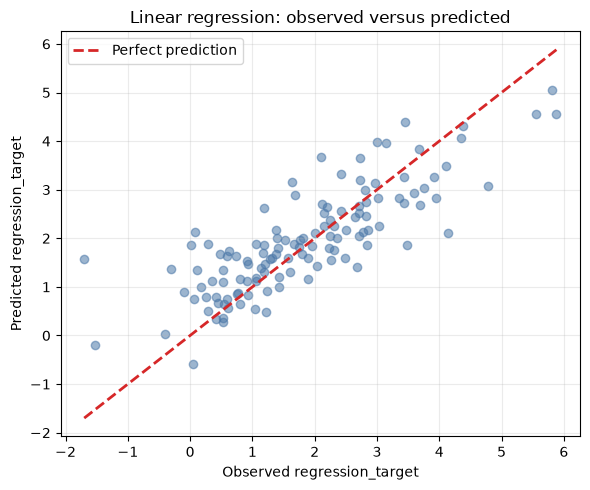

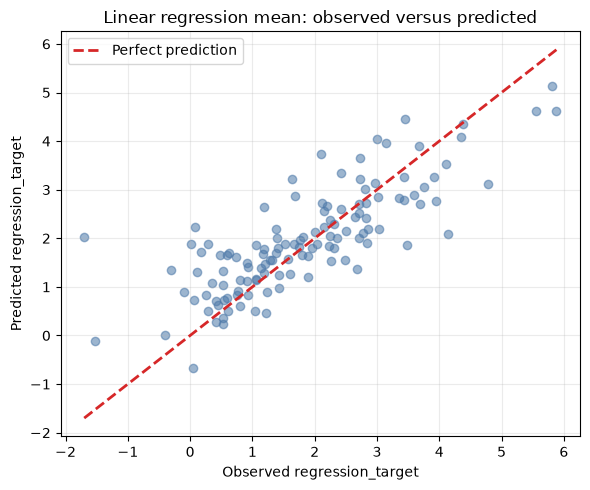

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954


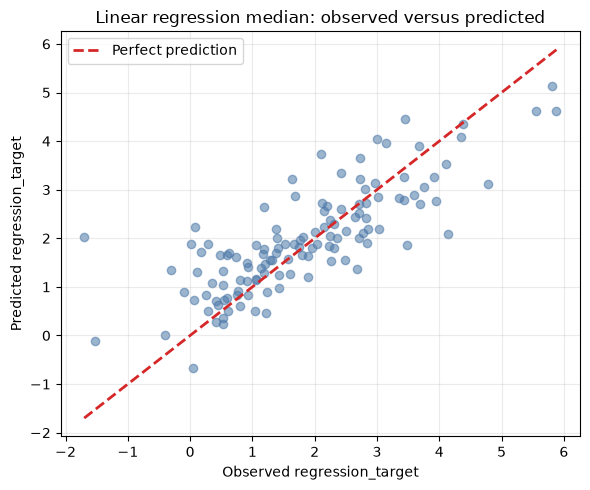

In [322]:
linear_model = Pipeline([("model", LinearRegression())])

linear_model.fit(X_train, y_train)
pred_linear = linear_model.predict(X_test)

regression_results.append(regression_metrics("Linear regression", y_test, pred_linear))

plot_observed_vs_predicted(
    y_test, pred_linear, "Linear regression: observed versus predicted"
)

linear_model = Pipeline([("model", LinearRegression())])

linear_model.fit(X_train_mean, y_train)
pred_linear = linear_model.predict(X_test_mean)

regression_results.append(
    regression_metrics("Linear regression mean", y_test, pred_linear)
)

plot_observed_vs_predicted(
    y_test, pred_linear, "Linear regression mean: observed versus predicted"
)

linear_model = Pipeline([("model", LinearRegression())])

linear_model.fit(X_train_median, y_train)
pred_linear = linear_model.predict(X_test_median)

regression_results.append(
    regression_metrics("Linear regression median", y_test, pred_linear)
)

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(
    y_test, pred_linear, "Linear regression median: observed versus predicted"
)

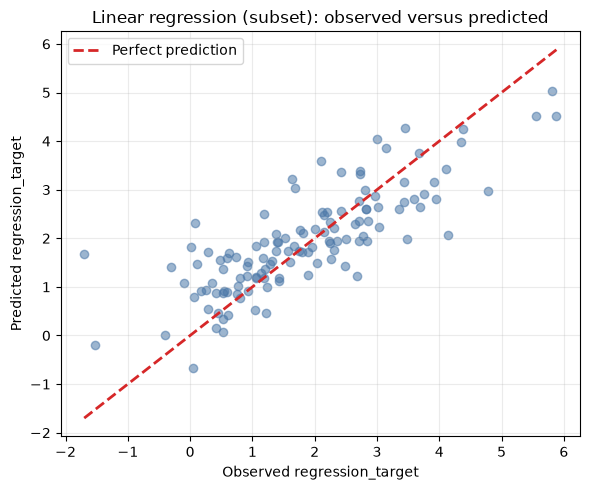

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425


In [323]:
linear_model = Pipeline([("model", LinearRegression())])

linear_model.fit(X_train[subset_of_features], y_train)
pred_linear = linear_model.predict(X_test[subset_of_features])

regression_results.append(
    regression_metrics("Linear regression (subset)", y_test, pred_linear)
)

plot_observed_vs_predicted(
    y_test, pred_linear, "Linear regression (subset): observed versus predicted"
)
display(pd.DataFrame(regression_results))

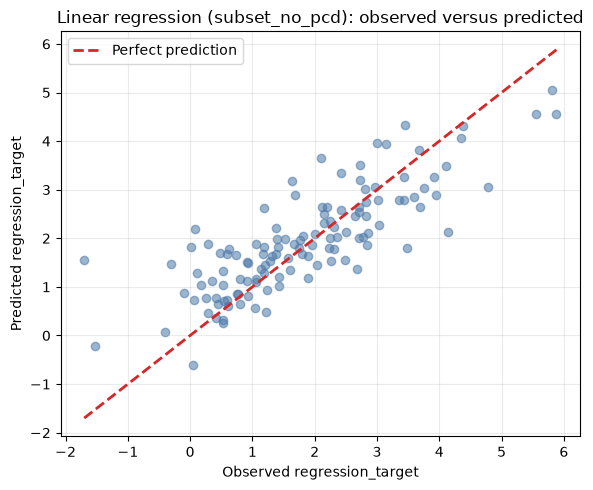

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606


In [324]:
linear_model = Pipeline([("model", LinearRegression())])

linear_model.fit(X_train[subset_no_pcd], y_train)
pred_linear = linear_model.predict(X_test[subset_no_pcd])

regression_results.append(
    regression_metrics("Linear regression (subset_no_pcd)", y_test, pred_linear)
)

plot_observed_vs_predicted(
    y_test, pred_linear, "Linear regression (subset_no_pcd): observed versus predicted"
)
display(pd.DataFrame(regression_results))

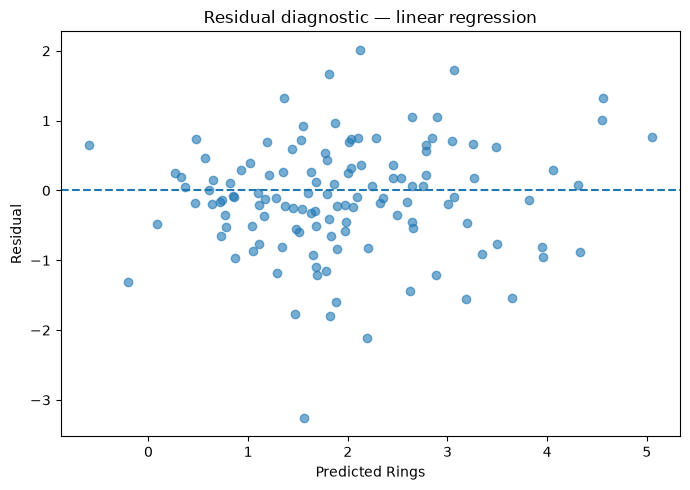

In [325]:
# only for iterative imputer, as it performed the best
residuals = y_test.to_numpy() - pred_linear

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pred_linear, residuals, alpha=0.6)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Predicted Rings")
ax.set_ylabel("Residual")
ax.set_title("Residual diagnostic — linear regression")
plt.tight_layout()
plt.show()

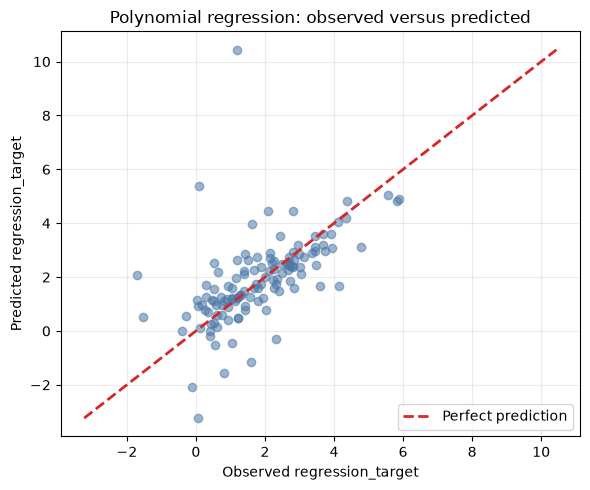

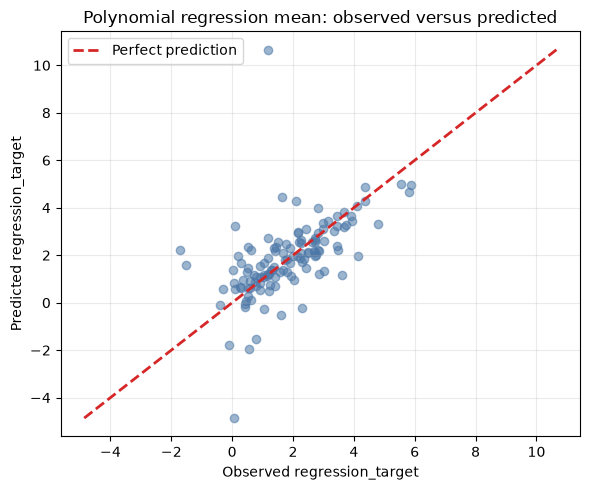

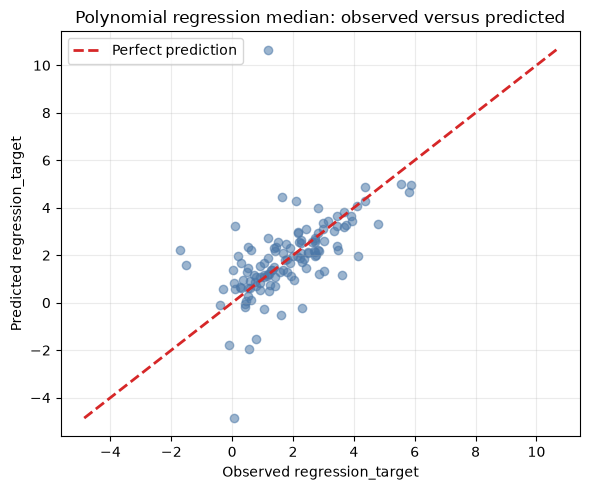

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620


In [326]:
poly_model = Pipeline(
    [
        (
            "poly",
            PolynomialFeatures(degree=3, include_bias=False, interaction_only=False),
        ),
        ("model", Ridge(alpha=1.0)),
    ]
)

poly_model.fit(X_train, y_train)
pred_poly = poly_model.predict(X_test)

regression_results.append(
    regression_metrics("Polynomial (degree 3)", y_test, pred_poly)
)
plot_observed_vs_predicted(
    y_test, pred_poly, "Polynomial regression: observed versus predicted"
)

poly_model = Pipeline(
    [
        (
            "poly",
            PolynomialFeatures(degree=3, include_bias=False, interaction_only=False),
        ),
        ("model", Ridge(alpha=1.0)),
    ]
)

poly_model.fit(X_train_mean, y_train)
pred_poly = poly_model.predict(X_test_mean)

regression_results.append(
    regression_metrics("Polynomial (degree 3) mean", y_test, pred_poly)
)
plot_observed_vs_predicted(
    y_test, pred_poly, "Polynomial regression mean: observed versus predicted"
)

poly_model = Pipeline(
    [
        (
            "poly",
            PolynomialFeatures(degree=3, include_bias=False, interaction_only=False),
        ),
        ("model", Ridge(alpha=1.0)),
    ]
)

poly_model.fit(X_train_median, y_train)
pred_poly = poly_model.predict(X_test_median)

regression_results.append(
    regression_metrics("Polynomial (degree 3) median", y_test, pred_poly)
)
plot_observed_vs_predicted(
    y_test, pred_poly, "Polynomial regression median: observed versus predicted"
)
display(pd.DataFrame(regression_results))

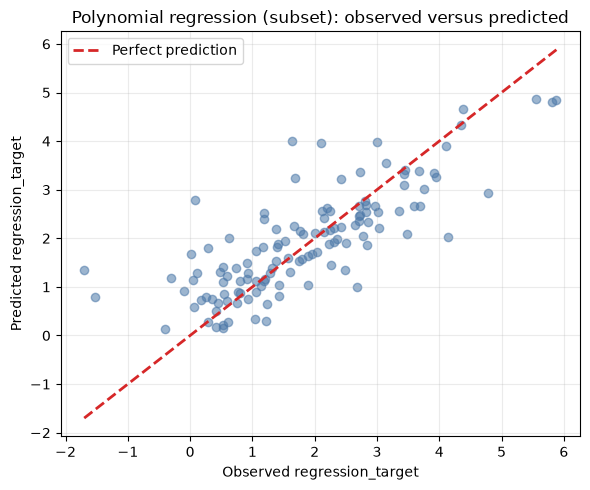

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025


In [327]:
poly_model = Pipeline(
    [
        (
            "poly",
            PolynomialFeatures(degree=3, include_bias=False, interaction_only=False),
        ),
        ("model", Ridge(alpha=1.0)),
    ]
)

poly_model.fit(X_train[subset_of_features], y_train)
pred_poly = poly_model.predict(X_test[subset_of_features])

regression_results.append(
    regression_metrics("Polynomial (degree 3) (subset)", y_test, pred_poly)
)
plot_observed_vs_predicted(
    y_test, pred_poly, "Polynomial regression (subset): observed versus predicted"
)
display(pd.DataFrame(regression_results))

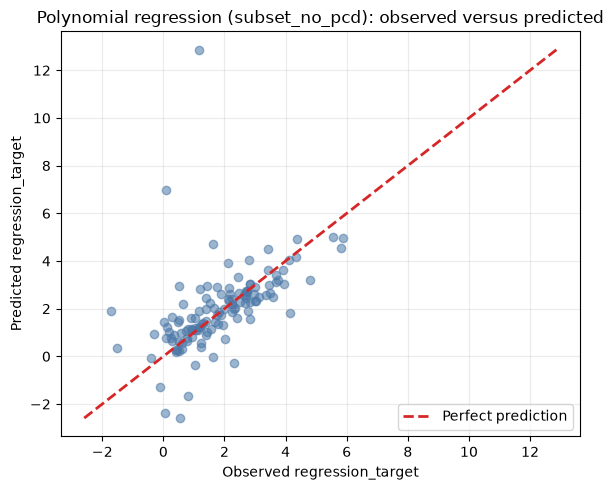

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


In [328]:
poly_model = Pipeline(
    [
        (
            "poly",
            PolynomialFeatures(degree=3, include_bias=False, interaction_only=False),
        ),
        ("model", Ridge(alpha=1.0)),
    ]
)

poly_model.fit(X_train[subset_no_pcd], y_train)
pred_poly = poly_model.predict(X_test[subset_no_pcd])

regression_results.append(
    regression_metrics("Polynomial (degree 3) (subset_no_pcd)", y_test, pred_poly)
)
plot_observed_vs_predicted(
    y_test,
    pred_poly,
    "Polynomial regression (subset_no_pcd): observed versus predicted",
)
display(pd.DataFrame(regression_results))

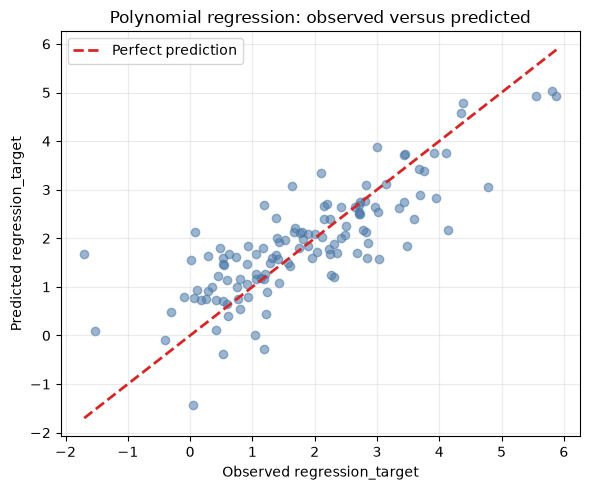

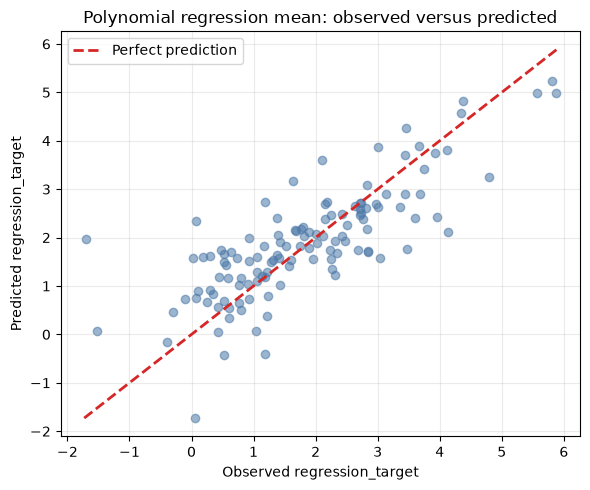

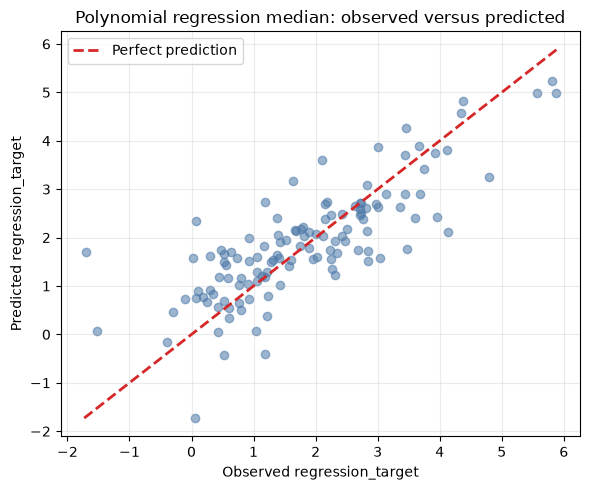

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


In [329]:
poly_model = Pipeline(
    [
        (
            "poly",
            PolynomialFeatures(degree=2, include_bias=False, interaction_only=False),
        ),
        ("model", Ridge(alpha=1.0)),
    ]
)

poly_model.fit(X_train, y_train)
pred_poly = poly_model.predict(X_test)

regression_results.append(
    regression_metrics("Polynomial (degree 2)", y_test, pred_poly)
)
plot_observed_vs_predicted(
    y_test, pred_poly, "Polynomial regression: observed versus predicted"
)

poly_model = Pipeline(
    [
        (
            "poly",
            PolynomialFeatures(degree=2, include_bias=False, interaction_only=False),
        ),
        ("model", Ridge(alpha=1.0)),
    ]
)

poly_model.fit(X_train_mean, y_train)
pred_poly = poly_model.predict(X_test_mean)

regression_results.append(
    regression_metrics("Polynomial (degree 2) mean", y_test, pred_poly)
)
plot_observed_vs_predicted(
    y_test, pred_poly, "Polynomial regression mean: observed versus predicted"
)
poly_model = Pipeline(
    [
        (
            "poly",
            PolynomialFeatures(degree=2, include_bias=False, interaction_only=False),
        ),
        ("model", Ridge(alpha=1.0)),
    ]
)

poly_model.fit(X_train_median, y_train)
pred_poly = poly_model.predict(X_test)

regression_results.append(
    regression_metrics("Polynomial (degree 2) median", y_test, pred_poly)
)
plot_observed_vs_predicted(
    y_test, pred_poly, "Polynomial regression median: observed versus predicted"
)
display(pd.DataFrame(regression_results))


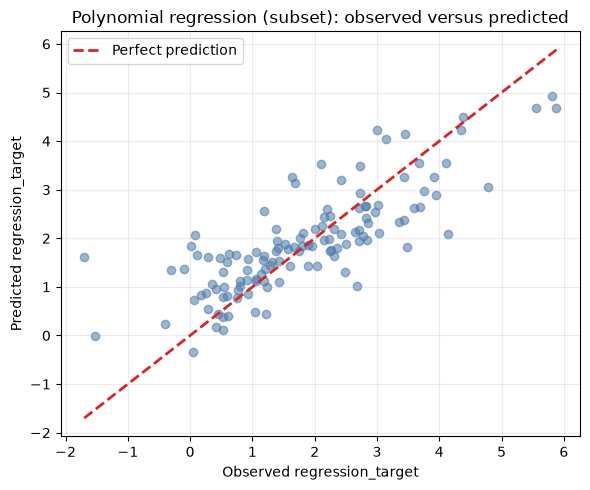

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


In [330]:
poly_model = Pipeline(
    [
        (
            "poly",
            PolynomialFeatures(degree=2, include_bias=False, interaction_only=False),
        ),
        ("model", Ridge(alpha=1.0)),
    ]
)

poly_model.fit(X_train[subset_of_features], y_train)
pred_poly = poly_model.predict(X_test[subset_of_features])

regression_results.append(
    regression_metrics("Polynomial (degree 2) (subset)", y_test, pred_poly)
)
plot_observed_vs_predicted(
    y_test, pred_poly, "Polynomial regression (subset): observed versus predicted"
)
display(pd.DataFrame(regression_results))

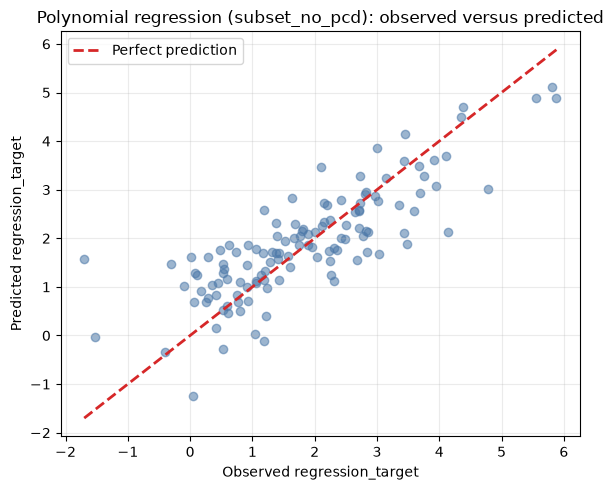

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


In [331]:
poly_model = Pipeline(
    [
        (
            "poly",
            PolynomialFeatures(degree=2, include_bias=False, interaction_only=False),
        ),
        ("model", Ridge(alpha=1.0)),
    ]
)

poly_model.fit(X_train[subset_no_pcd], y_train)
pred_poly = poly_model.predict(X_test[subset_no_pcd])

regression_results.append(
    regression_metrics("Polynomial (degree 2) (subset_no_pcd)", y_test, pred_poly)
)
plot_observed_vs_predicted(
    y_test,
    pred_poly,
    "Polynomial regression (subset_no_pcd): observed versus predicted",
)
display(pd.DataFrame(regression_results))

As iterative imputer performed the best for all 3, the other models are using it only

Continuing trying no PCD option, as it seems to bring small improvements

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


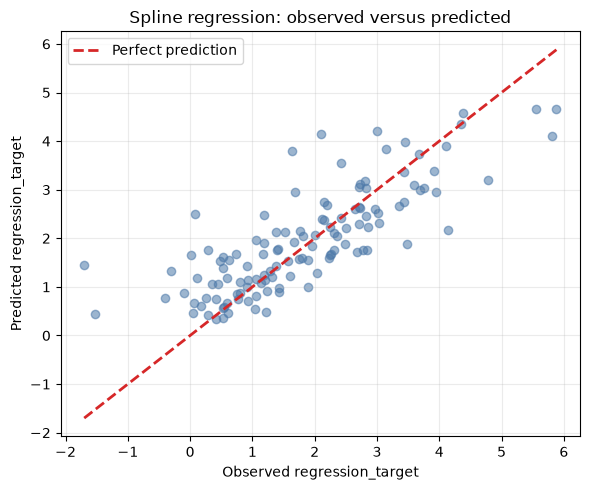

In [332]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
spline_preprocessor = ColumnTransformer(
    [
        (
            "num_spline",
            Pipeline(
                [
                    ("scale", StandardScaler()),
                    (
                        "spline",
                        SplineTransformer(n_knots=5, degree=3, include_bias=False),
                    ),
                ]
            ),
            num_cols,
        )
    ]
)

spline_model = Pipeline([("prep", spline_preprocessor), ("model", Ridge(alpha=1.0))])

spline_model.fit(X_train, y_train)
pred_spline = spline_model.predict(X_test)

regression_results.append(regression_metrics("Spline + Ridge", y_test, pred_spline))

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(
    y_test, pred_spline, "Spline regression: observed versus predicted"
)

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


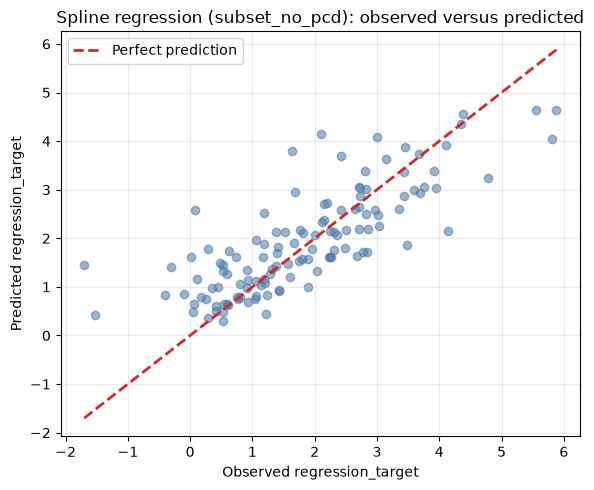

In [333]:
num_cols = X[subset_no_pcd].select_dtypes(include=np.number).columns.tolist()
spline_preprocessor = ColumnTransformer(
    [
        (
            "num_spline",
            Pipeline(
                [
                    ("scale", StandardScaler()),
                    (
                        "spline",
                        SplineTransformer(n_knots=5, degree=3, include_bias=False),
                    ),
                ]
            ),
            num_cols,
        )
    ]
)

spline_model = Pipeline([("prep", spline_preprocessor), ("model", Ridge(alpha=1.0))])

spline_model.fit(X_train[subset_no_pcd], y_train)
pred_spline = spline_model.predict(X_test[subset_no_pcd])

regression_results.append(
    regression_metrics("Spline + Ridge (subset_no_pcd)", y_test, pred_spline)
)

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(
    y_test, pred_spline, "Spline regression (subset_no_pcd): observed versus predicted"
)

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


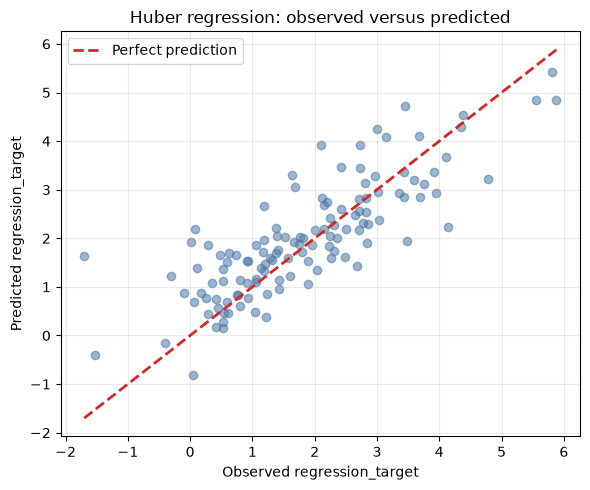

In [334]:
huber_model = Pipeline([("model", HuberRegressor(max_iter=3000))])

huber_model.fit(X_train, y_train)
pred_huber = huber_model.predict(X_test)

regression_results.append(regression_metrics("Huber regression", y_test, pred_huber))

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(
    y_test, pred_huber, "Huber regression: observed versus predicted"
)

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


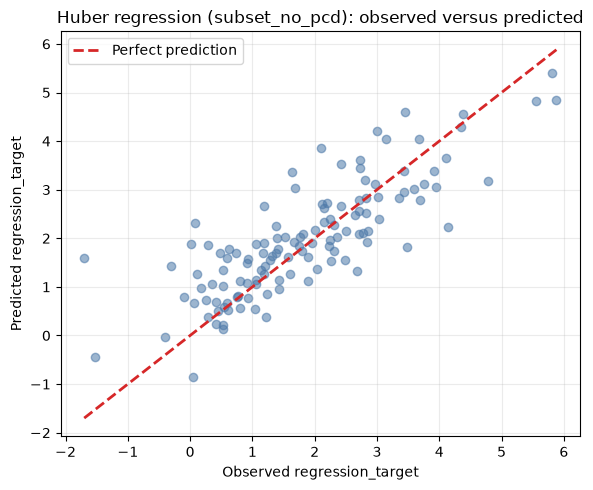

In [335]:
huber_model = Pipeline([("model", HuberRegressor(max_iter=3000))])

huber_model.fit(X_train[subset_no_pcd], y_train)
pred_huber = huber_model.predict(X_test[subset_no_pcd])

regression_results.append(
    regression_metrics("Huber regression (subset_no_pcd)", y_test, pred_huber)
)

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(
    y_test, pred_huber, "Huber regression (subset_no_pcd): observed versus predicted"
)

In [336]:
quantile_model = Pipeline(
    [("model", QuantileRegressor(quantile=0.25, alpha=0.01, solver="highs"))]
)

quantile_model.fit(X_train, y_train)
pred_quantile = quantile_model.predict(X_test)

regression_results.append(
    regression_metrics("Quantile regression (25)", y_test, pred_quantile)
)

display(pd.DataFrame(regression_results))

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


In [337]:
quantile_model = Pipeline(
    [("model", QuantileRegressor(quantile=0.25, alpha=0.01, solver="highs"))]
)

quantile_model.fit(X_train[subset_no_pcd], y_train)
pred_quantile = quantile_model.predict(X_test[subset_no_pcd])

regression_results.append(
    regression_metrics(
        "Quantile regression (25) (subset_no_pcd)", y_test, pred_quantile
    )
)

display(pd.DataFrame(regression_results))

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


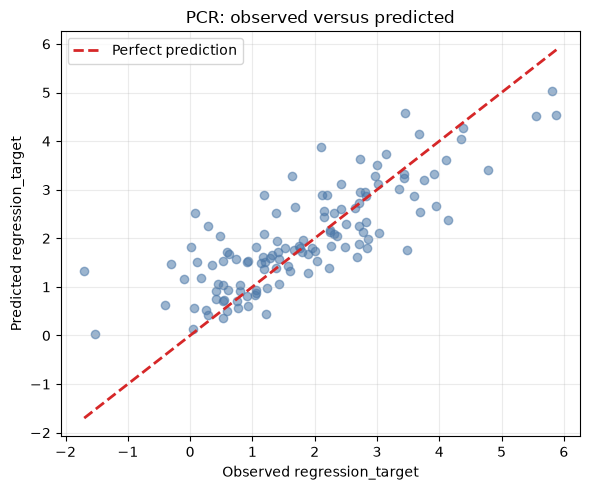

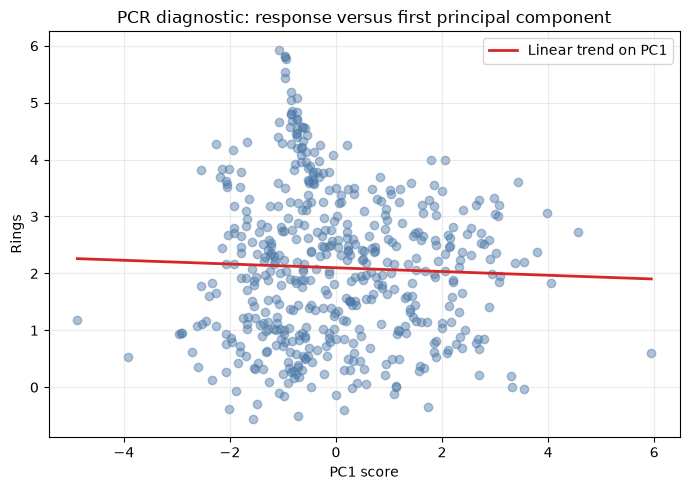

In [338]:
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), num_cols)])
pcr_model = Pipeline(
    [
        ("prep", preprocessor),
        ("pca", PCA(n_components=5)),
        ("model", LinearRegression()),
    ]
)

pcr_model.fit(X_train, y_train)
pred_pcr = pcr_model.predict(X_test)

regression_results.append(regression_metrics("PCR (5 PCs)", y_test, pred_pcr))

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(y_test, pred_pcr, "PCR: observed versus predicted")

# Visualize the first principal component as a one-dimensional diagnostic.
X_train_pca = pcr_model.named_steps["pca"].transform(
    pcr_model.named_steps["prep"].transform(X_train)
)
pc1 = X_train_pca[:, 0]
pc1_line = np.polyfit(pc1, y_train.to_numpy(), deg=1)
pc1_grid = np.linspace(pc1.min(), pc1.max(), 100)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pc1, y_train, alpha=0.45, color="#4c78a8")
ax.plot(
    pc1_grid,
    np.polyval(pc1_line, pc1_grid),
    color="#d62728",
    linewidth=2,
    label="Linear trend on PC1",
)
ax.set_xlabel("PC1 score")
ax.set_ylabel("Rings")
ax.set_title("PCR diagnostic: response versus first principal component")
ax.grid(alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


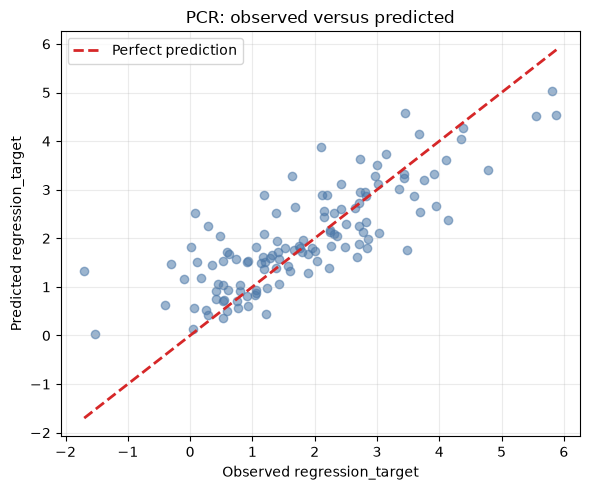

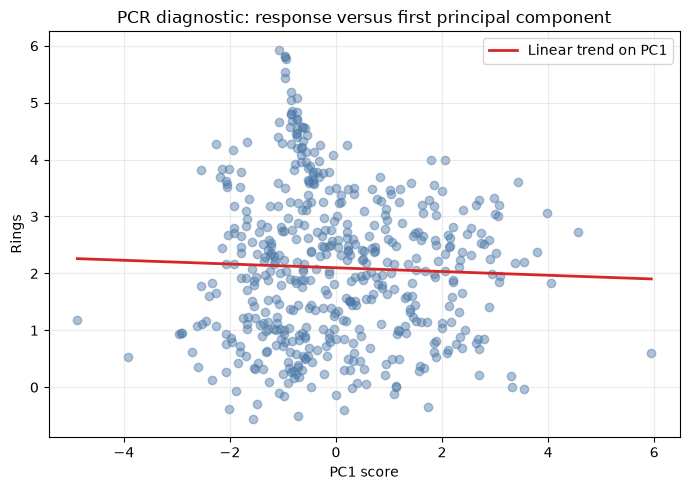

In [339]:
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), num_cols)])
pcr_model = Pipeline(
    [
        ("prep", preprocessor),
        ("pca", PCA(n_components=5)),
        ("model", LinearRegression()),
    ]
)

pcr_model.fit(X_train[subset_no_pcd], y_train)
pred_pcr = pcr_model.predict(X_test[subset_no_pcd])

regression_results.append(
    regression_metrics("PCR (5 PCs) (subset_no_pcd)", y_test, pred_pcr)
)

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(y_test, pred_pcr, "PCR: observed versus predicted")

# Visualize the first principal component as a one-dimensional diagnostic.
X_train_pca = pcr_model.named_steps["pca"].transform(
    pcr_model.named_steps["prep"].transform(X_train)
)
pc1 = X_train_pca[:, 0]
pc1_line = np.polyfit(pc1, y_train.to_numpy(), deg=1)
pc1_grid = np.linspace(pc1.min(), pc1.max(), 100)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pc1, y_train, alpha=0.45, color="#4c78a8")
ax.plot(
    pc1_grid,
    np.polyval(pc1_line, pc1_grid),
    color="#d62728",
    linewidth=2,
    label="Linear trend on PC1",
)
ax.set_xlabel("PC1 score")
ax.set_ylabel("Rings")
ax.set_title("PCR diagnostic: response versus first principal component")
ax.grid(alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


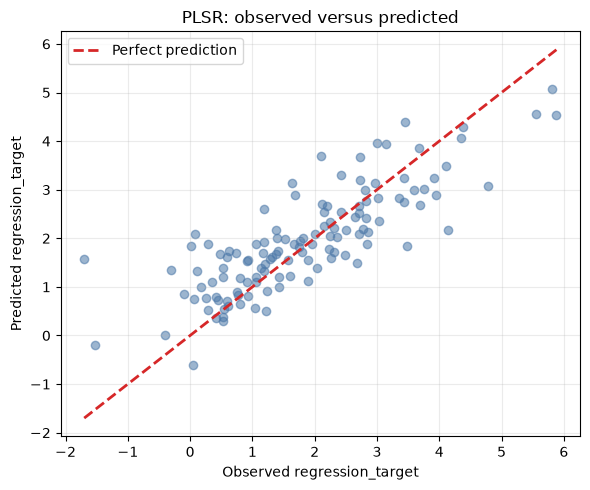

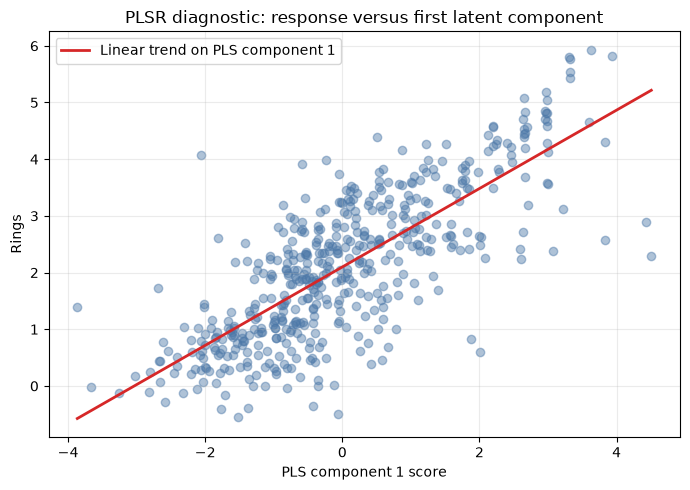

In [340]:
pls = PLSRegression(n_components=5)
pls.fit(X_train, y_train)

pred_pls = pls.predict(X_test).ravel()

regression_results.append(regression_metrics("PLSR (5 components)", y_test, pred_pls))

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(y_test, pred_pls, "PLSR: observed versus predicted")

pls1 = pls.x_scores_[:, 0]
pls1_line = np.polyfit(pls1, y_train.to_numpy(), deg=1)
pls1_grid = np.linspace(pls1.min(), pls1.max(), 100)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pls1, y_train, alpha=0.45, color="#4c78a8")
ax.plot(
    pls1_grid,
    np.polyval(pls1_line, pls1_grid),
    color="#d62728",
    linewidth=2,
    label="Linear trend on PLS component 1",
)
ax.set_xlabel("PLS component 1 score")
ax.set_ylabel("Rings")
ax.set_title("PLSR diagnostic: response versus first latent component")
ax.grid(alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


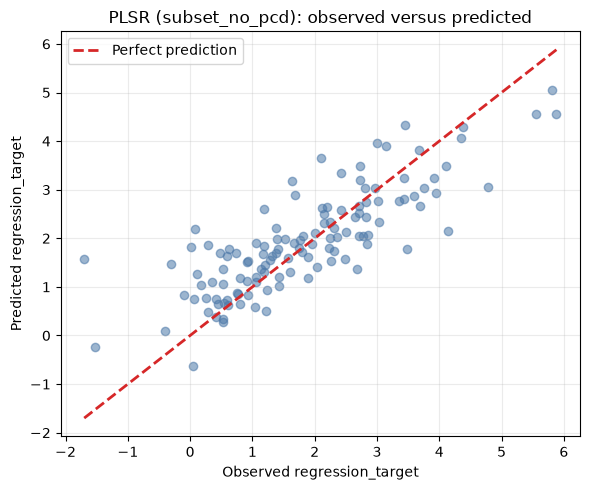

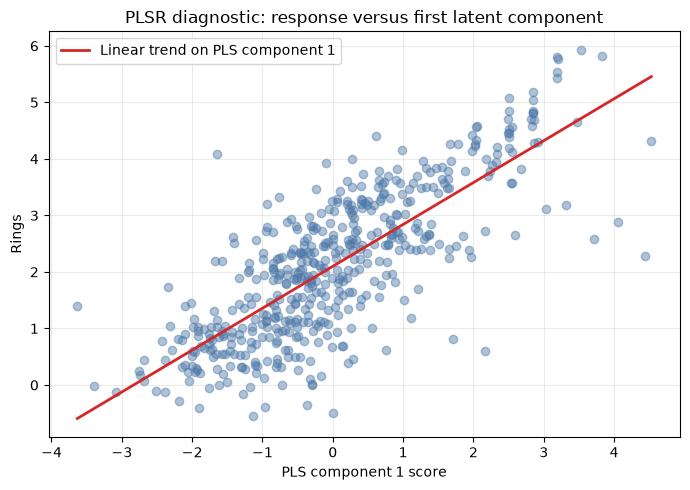

In [341]:
pls = PLSRegression(n_components=5)
pls.fit(X_train[subset_no_pcd], y_train)

pred_pls = pls.predict(X_test[subset_no_pcd]).ravel()

regression_results.append(
    regression_metrics("PLSR (5 components) (subset_no_pcd)", y_test, pred_pls)
)

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(
    y_test, pred_pls, "PLSR (subset_no_pcd): observed versus predicted"
)

pls1 = pls.x_scores_[:, 0]
pls1_line = np.polyfit(pls1, y_train.to_numpy(), deg=1)
pls1_grid = np.linspace(pls1.min(), pls1.max(), 100)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pls1, y_train, alpha=0.45, color="#4c78a8")
ax.plot(
    pls1_grid,
    np.polyval(pls1_line, pls1_grid),
    color="#d62728",
    linewidth=2,
    label="Linear trend on PLS component 1",
)
ax.set_xlabel("PLS component 1 score")
ax.set_ylabel("Rings")
ax.set_title("PLSR diagnostic: response versus first latent component")
ax.grid(alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

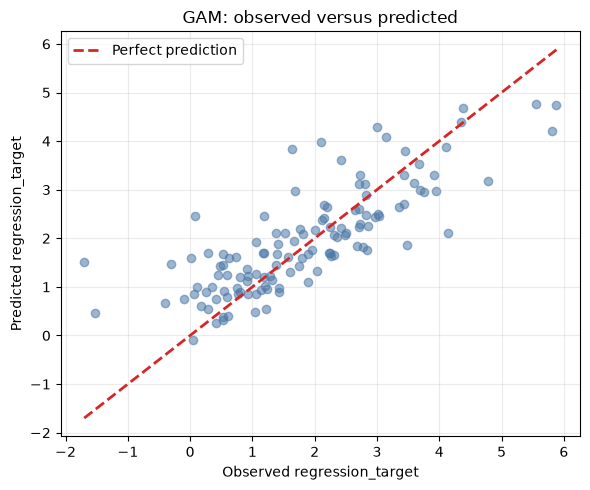

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


In [342]:
try:
    from pygam import LinearGAM, s

    X_gam_train = X_train.to_numpy()
    X_gam_test = X_test.to_numpy()

    # One smooth term per numeric predictor
    gam = LinearGAM(
        s(0, n_splines=10)
        + s(1, n_splines=10)
        + s(2, n_splines=10)
        + s(3, n_splines=10)
        + s(4, n_splines=10)
        + s(5, n_splines=10)
        + s(6, n_splines=10)
    ).fit(X_gam_train, y_train)

    pred_gam = gam.predict(X_gam_test)

    regression_results.append(regression_metrics("GAM", y_test, pred_gam))
    plot_observed_vs_predicted(y_test, pred_gam, "GAM: observed versus predicted")

except Exception as e:
    print("GAM was not run:", e)
    print("Install pygam to execute this section.")

display(pd.DataFrame(regression_results))

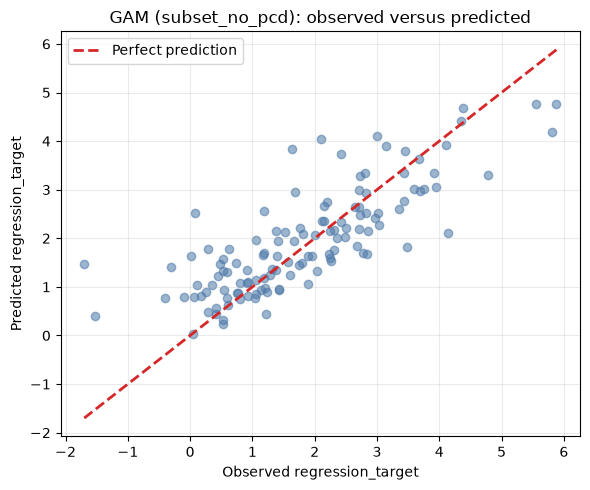

,model,MAE,RMSE,R2
0,Linear regression,0.608286,0.805924,0.660441
1,Linear regression mean,0.615152,0.831033,0.638954
2,Linear regression median,0.615152,0.831033,0.638954
3,Linear regression (subset),0.622002,0.821226,0.647425
4,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
5,Polynomial (degree 3),0.829340,1.391724,-0.012588
6,Polynomial (degree 3) mean,0.843366,1.419641,-0.053620
7,Polynomial (degree 3) median,0.843366,1.419641,-0.053620
8,Polynomial (degree 3) (subset),0.613320,0.843517,0.628025
9,Polynomial (degree 3) (subset_no_pcd),0.834084,1.567577,-0.284649


In [343]:
try:
    from pygam import LinearGAM, s

    X_gam_train = X_train[subset_no_pcd].to_numpy()
    X_gam_test = X_test[subset_no_pcd].to_numpy()

    # One smooth term per numeric predictor
    gam = LinearGAM(
        s(0, n_splines=10)
        + s(1, n_splines=10)
        + s(2, n_splines=10)
        + s(3, n_splines=10)
        + s(4, n_splines=10)
        + s(5, n_splines=10)
        + s(6, n_splines=10)
    ).fit(X_gam_train, y_train)

    pred_gam = gam.predict(X_gam_test)

    regression_results.append(
        regression_metrics("GAM (subset_no_pcd)", y_test, pred_gam)
    )
    plot_observed_vs_predicted(
        y_test, pred_gam, "GAM (subset_no_pcd): observed versus predicted"
    )

except Exception as e:
    print("GAM was not run:", e)
    print("Install pygam to execute this section.")

display(pd.DataFrame(regression_results))

/Users/otsep/Desktop/Personal/KSE/ml/personal/KSE_ML_for_bioinformatics/.venv/lib/python3.11/site-packages/pysr/sr.py:2405: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


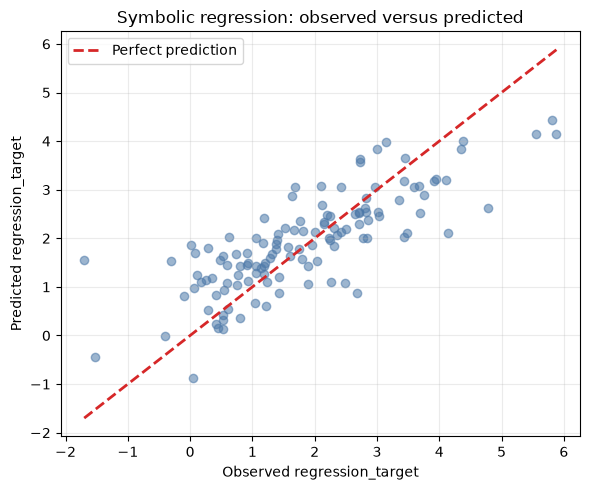

Selected symbolic equation:


MLOGP + 2.0987132

In [344]:
X_sym_train = X_train.to_numpy()
X_sym_test = X_test.to_numpy()
sym_features = X_train.columns.str.replace(r"[^a-zA-Z0-9_]", "_", regex=True).tolist()

sym_scaler = StandardScaler()
X_sym_train_s = sym_scaler.fit_transform(X_sym_train)
X_sym_test_s = sym_scaler.transform(X_sym_test)

try:
    from pysr import PySRRegressor

    symbolic_model = PySRRegressor(
        niterations=10,
        populations=10,
        population_size=20,
        binary_operators=["+", "-", "*", "/"],
        unary_operators=["square", "cube", "cos", "exp", "sin", "sqrt"],
        maxsize=10,
        random_state=RANDOM_STATE,
        verbosity=0,
    )

    symbolic_model.fit(X_sym_train_s, y_train, variable_names=sym_features)

    pred_symbolic = symbolic_model.predict(X_sym_test_s)

    regression_results.append(
        regression_metrics("Symbolic regression", y_test, pred_symbolic)
    )
    plot_observed_vs_predicted(
        y_test, pred_symbolic, "Symbolic regression: observed versus predicted"
    )

    print("Selected symbolic equation:")
    display(symbolic_model.sympy())

except Exception as e:
    print("Symbolic regression was not run:", e)
    print("Install/configure PySR, then rerun this cell.")

/Users/otsep/Desktop/Personal/KSE/ml/personal/KSE_ML_for_bioinformatics/.venv/lib/python3.11/site-packages/pysr/sr.py:2405: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


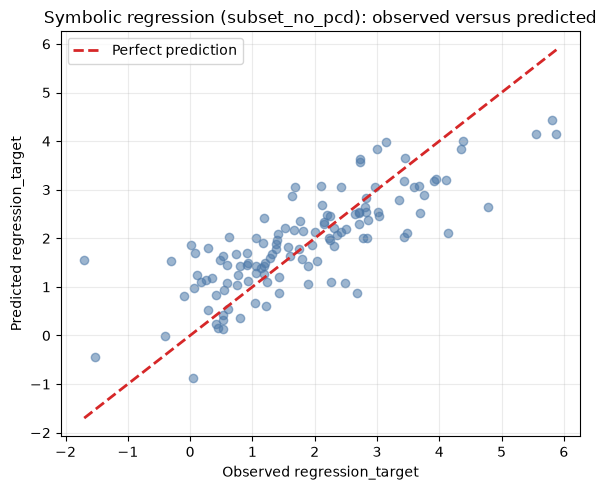

Selected symbolic equation:


MLOGP + 2.0989792

In [ ]:
X_sym_train = X_train[subset_no_pcd].to_numpy()
X_sym_test = X_test[subset_no_pcd].to_numpy()
sym_features = (
    X_train[subset_no_pcd]
    .columns.str.replace(r"[^a-zA-Z0-9_]", "_", regex=True)
    .tolist()
)

sym_scaler = StandardScaler()
X_sym_train_s = sym_scaler.fit_transform(X_sym_train)
X_sym_test_s = sym_scaler.transform(X_sym_test)

try:
    from pysr import PySRRegressor

    symbolic_model = PySRRegressor(
        niterations=10,
        populations=10,
        population_size=20,
        binary_operators=["+", "-", "*", "/"],
        unary_operators=["square", "cube", "cos", "exp", "sin", "sqrt"],
        maxsize=10,
        random_state=RANDOM_STATE,
        verbosity=0,
    )

    symbolic_model.fit(X_sym_train_s, y_train, variable_names=sym_features)

    pred_symbolic = symbolic_model.predict(X_sym_test_s)

    regression_results.append(
        regression_metrics("Symbolic regression (subset_no_pcd)", y_test, pred_symbolic)
    )
    plot_observed_vs_predicted(
        y_test,
        pred_symbolic,
        "Symbolic regression (subset_no_pcd): observed versus predicted",
    )

    print("Selected symbolic equation:")
    display(symbolic_model.sympy())

except Exception as e:
    print("Symbolic regression was not run:", e)
    print("Install/configure PySR, then rerun this cell.")

In [346]:
regression_table = (
    pd.DataFrame(regression_results).sort_values("RMSE").reset_index(drop=True)
)

display(regression_table)

,model,MAE,RMSE,R2
0,Polynomial (degree 2) (subset_no_pcd),0.606006,0.797981,0.667102
1,PLSR (5 components),0.605759,0.802236,0.663542
2,Polynomial (degree 2),0.608525,0.805669,0.660656
3,Linear regression,0.608286,0.805924,0.660441
4,PLSR (5 components) (subset_no_pcd),0.608162,0.807329,0.659256
5,Linear regression (subset_no_pcd),0.607807,0.808099,0.658606
6,Huber regression,0.608891,0.808808,0.658007
7,Huber regression (subset_no_pcd),0.607970,0.811328,0.655872
8,Linear regression (subset),0.622002,0.821226,0.647425
9,Polynomial (degree 2) (subset),0.623182,0.826390,0.642976


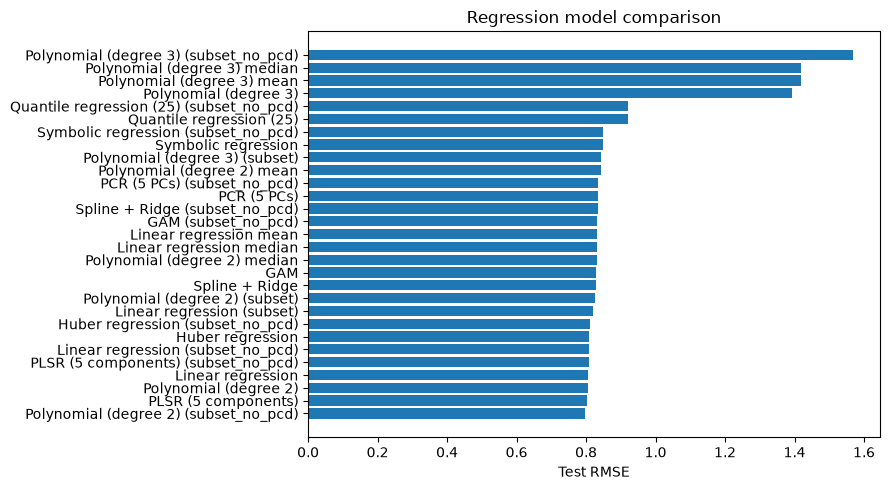

In [347]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = regression_table.sort_values("RMSE", ascending=True)
ax.barh(plot_df["model"], plot_df["RMSE"])
ax.set_xlabel("Test RMSE")
ax.set_title("Regression model comparison")
plt.tight_layout()
plt.show()

## Classificaion

In [348]:
X_cls = imputation_train.drop(columns=["classification_target", "regression_target"])
y_cls = imputation_train["classification_target"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cls
)

classification_model = Pipeline(
    [
        (
            "interactions",
            PolynomialFeatures(degree=2, interaction_only=True, include_bias=True),
        ),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced")),
    ]
)

classification_model.fit(Xc_train, yc_train)

cls_pred = classification_model.predict(Xc_test)
cls_proba = classification_model.predict_proba(Xc_test)

print(classification_report(yc_test, cls_pred))
print("Balanced accuracy:", balanced_accuracy_score(yc_test, cls_pred))
print("Macro F1:", f1_score(yc_test, cls_pred, average="macro"))

              precision    recall  f1-score   support

           1       0.69      0.64      0.66        74
           2       0.21      0.50      0.29        10
           3       0.55      0.44      0.49        41

    accuracy                           0.56       125
   macro avg       0.48      0.52      0.48       125
weighted avg       0.60      0.56      0.57       125

Balanced accuracy: 0.5247198417930125
Macro F1: 0.4808586548437419


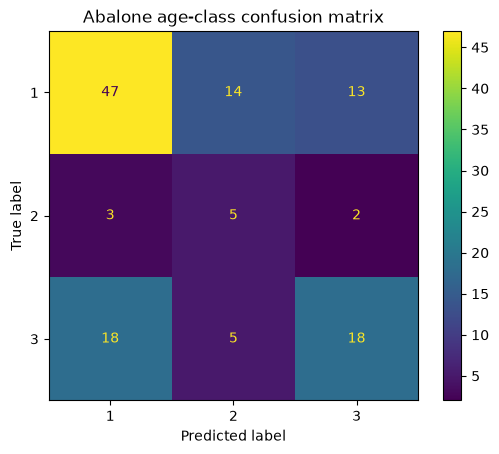

In [349]:
ConfusionMatrixDisplay.from_predictions(yc_test, cls_pred, cmap=None)

plt.title("Abalone age-class confusion matrix")
plt.show()

In [350]:
X_cls_with_rt = imputation_train.drop(columns=["classification_target"])
y_cls = imputation_train["classification_target"]

Xc_train_with_rt, Xc_test_with_rt, yc_train, yc_test = train_test_split(
    X_cls_with_rt, y_cls, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cls
)

classification_model_with_rt = Pipeline(
    [("model", LogisticRegression(max_iter=3000, class_weight="balanced"))]
)

classification_model_with_rt.fit(Xc_train_with_rt, yc_train)

cls_pred = classification_model_with_rt.predict(Xc_test_with_rt)
cls_proba = classification_model_with_rt.predict_proba(Xc_test_with_rt)

print(classification_report(yc_test, cls_pred))
print("Balanced accuracy:", balanced_accuracy_score(yc_test, cls_pred))
print("Macro F1:", f1_score(yc_test, cls_pred, average="macro"))

              precision    recall  f1-score   support

           1       0.82      0.66      0.73        74
           2       0.37      0.70      0.48        10
           3       0.70      0.78      0.74        41

    accuracy                           0.70       125
   macro avg       0.63      0.71      0.65       125
weighted avg       0.74      0.70      0.71       125

Balanced accuracy: 0.7142166556800703
Macro F1: 0.6499113627265969


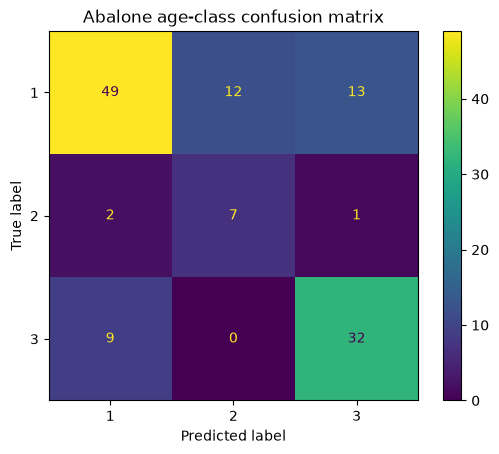

In [351]:
ConfusionMatrixDisplay.from_predictions(yc_test, cls_pred, cmap=None)

plt.title("Abalone age-class confusion matrix")
plt.show()

In [ ]:
Xc_test_pred_rt = Xc_test.copy()
Xc_test_pred_rt["regression_target"] = poly_model.predict(
    Xc_test_pred_rt[subset_no_pcd]
).ravel()


cls_pred = classification_model_with_rt.predict(Xc_test_pred_rt)
cls_proba = classification_model_with_rt.predict_proba(Xc_test_pred_rt)

print(classification_report(yc_test, cls_pred))
print("Balanced accuracy:", balanced_accuracy_score(yc_test, cls_pred))
print("Macro F1:", f1_score(yc_test, cls_pred, average="macro"))

              precision    recall  f1-score   support

           1       0.70      0.61      0.65        74
           2       0.18      0.30      0.22        10
           3       0.55      0.59      0.56        41

    accuracy                           0.58       125
   macro avg       0.48      0.50      0.48       125
weighted avg       0.61      0.58      0.59       125

Balanced accuracy: 0.4978246539222149
Macro F1: 0.47970067253954723


In [ ]:
Xc_train_pred_rt = Xc_train.copy()
Xc_test_pred_rt = Xc_test.copy()
Xc_train_pred_rt["pls_predicted_regression"] = pls.predict(
    Xc_train_pred_rt[subset_no_pcd]
).ravel()
Xc_test_pred_rt["pls_predicted_regression"] = pls.predict(
    Xc_test_pred_rt[subset_no_pcd]
).ravel()

classification_model_pred_rt = Pipeline(
    [("model", LogisticRegression(max_iter=3000, class_weight="balanced"))]
)

classification_model_pred_rt.fit(Xc_train_pred_rt, yc_train)

cls_pred = classification_model_pred_rt.predict(Xc_test_pred_rt)
cls_proba = classification_model_pred_rt.predict_proba(Xc_test_pred_rt)

print(classification_report(yc_test, cls_pred))
print("Balanced accuracy:", balanced_accuracy_score(yc_test, cls_pred))
print("Macro F1:", f1_score(yc_test, cls_pred, average="macro"))

              precision    recall  f1-score   support

           1       0.70      0.50      0.58        74
           2       0.14      0.50      0.22        10
           3       0.50      0.44      0.47        41

    accuracy                           0.48       125
   macro avg       0.45      0.48      0.42       125
weighted avg       0.59      0.48      0.52       125

Balanced accuracy: 0.4796747967479675
Macro F1: 0.42253364574487473


In [354]:
# checking weights adjustment on simple classifier + regression prediction, on train
probas = classification_model_pred_rt.predict_proba(Xc_train_pred_rt)

best_balanced_acc = 0
best_threshold_multipliers_pred_rt = (1.0, 1.0, 1.0)

for w1 in [1.0]:
    for w2 in np.linspace(0.4, 1.5, 12):
        for w3 in np.linspace(0.8, 1.4, 7):
            multipliers = np.array([w1, w2, w3])
            adjusted_probas = probas * multipliers
            preds_idx = np.argmax(adjusted_probas, axis=1)
            preds = classification_model_pred_rt.classes_[preds_idx]
            score = balanced_accuracy_score(yc_train, preds)

            if score > best_balanced_acc:
                best_balanced_acc = score
                best_threshold_multipliers_pred_rt = multipliers

print(f"Best Balanced Accuracy: {best_balanced_acc:.4f}")
print(f"Optimal Class Multipliers : {best_threshold_multipliers_pred_rt}")


Best Balanced Accuracy: 0.5710
Optimal Class Multipliers : [1.  0.7 0.9]


In [355]:
# checking weights adjustment on simple classifier + regression prediction, on test
def predict_with_thresholds(model, X_data, multipliers):
    raw_probs = model.predict_proba(X_data)
    scaled_probs = raw_probs * multipliers
    final_pred_indices = np.argmax(scaled_probs, axis=1)
    return model.classes_[final_pred_indices]


cls_pred = predict_with_thresholds(
    classification_model_pred_rt, Xc_test_pred_rt, best_threshold_multipliers_pred_rt
)

print(classification_report(yc_test, cls_pred, zero_division=0))
print(f"Optimized Balanced Accuracy: {balanced_accuracy_score(yc_test, cls_pred):.4f}")


              precision    recall  f1-score   support

           1       0.71      0.68      0.69        74
           2       0.25      0.50      0.33        10
           3       0.54      0.46      0.50        41

    accuracy                           0.59       125
   macro avg       0.50      0.55      0.51       125
weighted avg       0.62      0.59      0.60       125

Optimized Balanced Accuracy: 0.5464


In [356]:
# checking weights adjustment on simple classifier, on train
probas = classification_model.predict_proba(Xc_train)

best_balanced_acc = 0
best_threshold_multipliers = (1.0, 1.0, 1.0)

for w1 in [1.0]:
    for w2 in np.linspace(0.4, 1.5, 12):
        for w3 in np.linspace(0.8, 1.4, 7):
            multipliers = np.array([w1, w2, w3])
            adjusted_probas = probas * multipliers
            preds_idx = np.argmax(adjusted_probas, axis=1)
            preds = classification_model.classes_[preds_idx]
            score = balanced_accuracy_score(yc_train, preds)

            if score > best_balanced_acc:
                best_balanced_acc = score
                best_threshold_multipliers = multipliers

print(f"Best Balanced Accuracy: {best_balanced_acc:.4f}")
print(f"Optimal Class Multipliers : {best_threshold_multipliers}")

Best Balanced Accuracy: 0.6693
Optimal Class Multipliers : [1.  1.1 1.4]


In [357]:
# checking weights adjustment on simple classifier, on test
def predict_with_thresholds(model, X_data, multipliers):
    raw_probs = model.predict_proba(X_data)
    scaled_probs = raw_probs * multipliers
    final_pred_indices = np.argmax(scaled_probs, axis=1)
    return model.classes_[final_pred_indices]


cls_pred = predict_with_thresholds(
    classification_model, Xc_test, best_threshold_multipliers
)

print(classification_report(yc_test, cls_pred, zero_division=0))
print(f"Optimized Balanced Accuracy: {balanced_accuracy_score(yc_test, cls_pred):.4f}")

              precision    recall  f1-score   support

           1       0.71      0.59      0.65        74
           2       0.25      0.50      0.33        10
           3       0.53      0.56      0.55        41

    accuracy                           0.58       125
   macro avg       0.50      0.55      0.51       125
weighted avg       0.62      0.58      0.59       125

Optimized Balanced Accuracy: 0.5519


## Predict true test

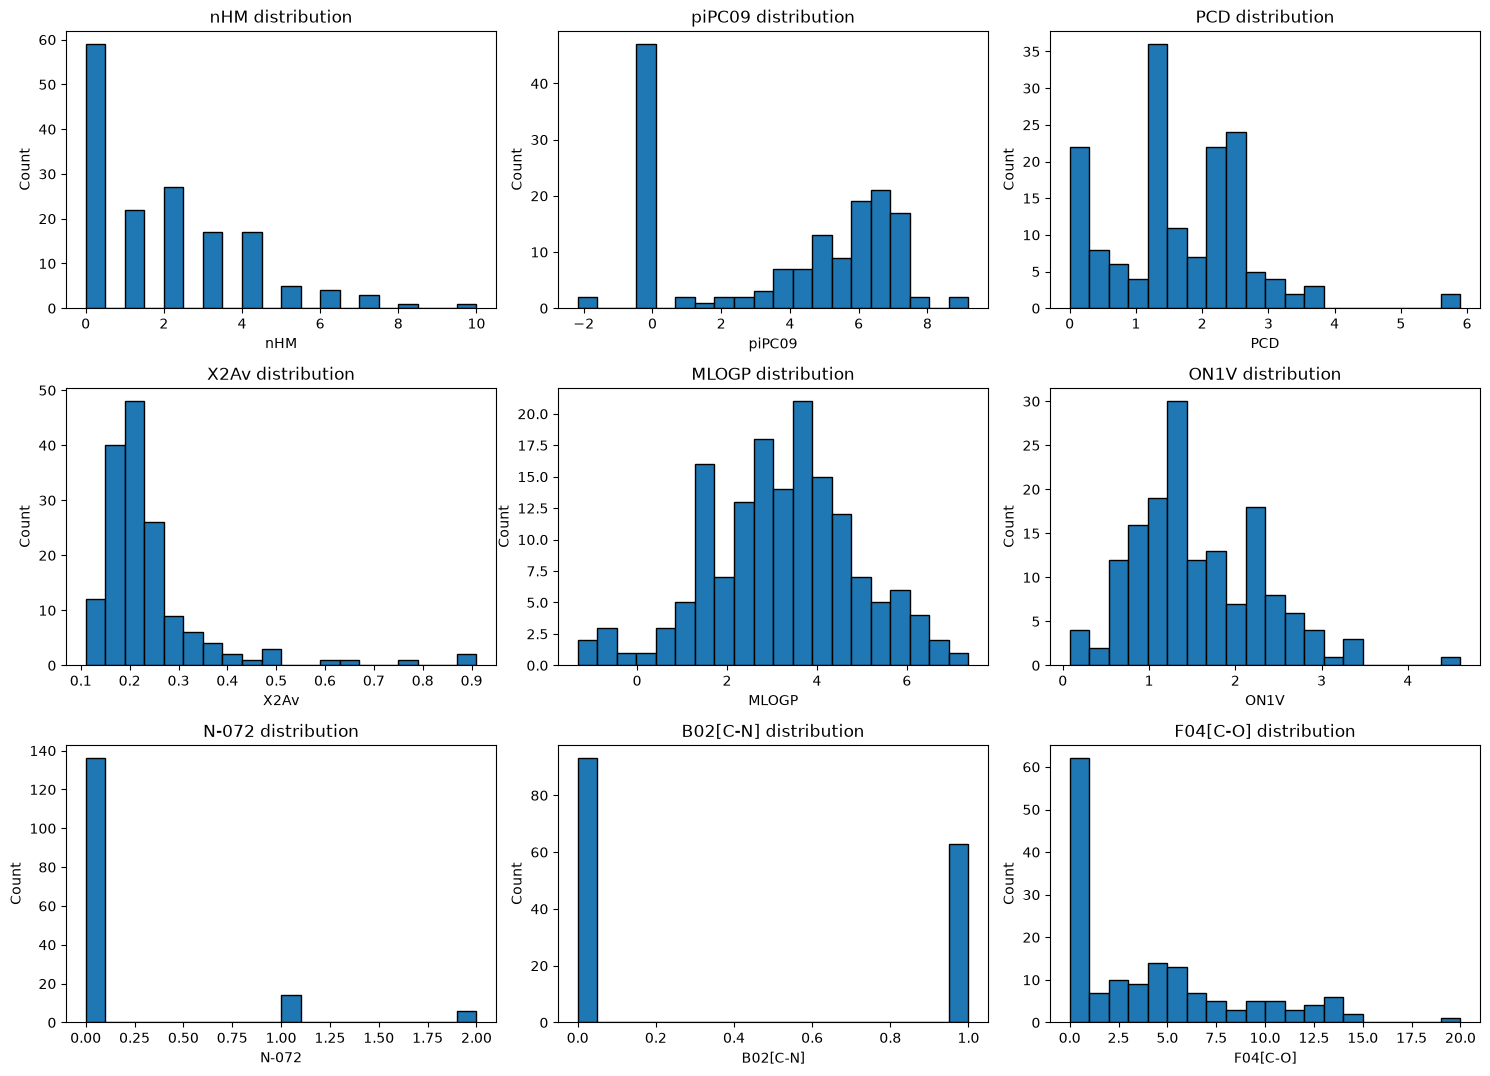

In [358]:
imputation_test = test.drop(columns="sample_id")
test_imputed = mice_im.transform(imputation_test)
imputation_test = pd.DataFrame(test_imputed, columns=imputation_test.columns)
imputation_test["nHM"] = imputation_test["nHM"].round().clip(lower=0)
imputation_test["N-072"] = imputation_test["N-072"].round().clip(lower=0)
imputation_test["B02[C-N]"] = imputation_test["B02[C-N]"].round().clip(lower=0)
imputation_test["F04[C-O]"] = imputation_test["F04[C-O]"].round().clip(lower=0)
visualize_col_distr(imputation_test)


In [ ]:
cls_pred = predict_with_thresholds(
    classification_model, imputation_test, best_threshold_multipliers
)
imputation_test["classification_target"] = cls_pred
imputation_test["poly_predicted_regression"] = poly_model.predict(
    imputation_test[subset_no_pcd]
).ravel()
submission_df = pd.DataFrame(
    {
        "sample_id": test["sample_id"],
        "regression_prediction": imputation_test["poly_predicted_regression"],
        "classification_prediction": imputation_test["classification_target"],
    }
)
display(submission_df.head())

,sample_id,regression_prediction,classification_prediction
0,78-79-5,0.923051,1
1,16606-02-3,4.070890,2
2,111-44-4,1.197010,1
3,107-05-1,0.841640,1
4,555-03-3,0.717627,1


In [360]:
submission_df.to_csv("simple_sub.csv")